# MGMT47400 Predictive Analytics: End-to-End Workflow Churn Exit Prediction

**Professor Davi Moreira**




This notebook presents an **end-to-end predictive modeling workflow**, using our course competition as a practical example.

Because the competition requires reproducibility, we set a fixed random seed (**SEED = 474**). The competition also provides a `test.csv` file without outcome labels. For this reason, the `test.csv` will only be used at the very end of the process to generate our final prediction output (`.csv` file) after training our selected model over the entire training set.

The modeling process follows this structure:

* The original `train.csv` is used for both **model training** and **model evaluation** (via cross-validation).
* Once the best-performing model is selected, it is retrained on the **entire training set** before generating predictions for `test.csv`.

In other contexts, where only a single dataset is available (and no separate test file exists), we typically consider two strategies:

1. **Train/Test Split with Cross-Validation**: Divide the dataset into training and validation subsets. Use cross-validation to train and evaluate candidate models, then select the one with the lowest estimated test error.

2. **Three-Way Split (Train/Validation/Test)**: Partition the dataset into three subsets. Use training and validation data with cross-validation to tune and compare models, and keep the test subset entirely unseen for the final performance estimate.

Our workflow will be organized in the following sequence. For each step, we will also provide an AI-prompt suggestion that can be used to request the corresponding Python code from an AI tool.

- Step 0 — Setup, configuration, and imports
- Step 1 — Data loading and sanity checks
- Step 2 — Exploratory Data Analysis (EDA)
- Step 3 — Data Preparation and Feature Engineering
- Step 4 — Basic Model
- Step 5 — More Complex Models
- Step 6 — Compare models with visualization
- Step 7 — Model selection and rationale
- Step 8 — Final training on the full training data
- Step 9 — Predict on the new observations (test set) and export the submission `.csv` file
- Step 99 — Reporting and reproducibility

## Step 0 — Setup, configuration, and imports

### **AI-Prompt**

Generate well-structured Python code that accomplishes the following:

1. **Import Libraries**: Import `pandas`, `numpy`, `matplotlib.pyplot`, and key modules from `sklearn` (`model_selection`, `metrics`, `preprocessing`, `compose`, `pipeline`, `linear_model`, `feature_selection`), as well as `plotly.express`.

2. **Reproducibility**: Define `SEED = 474` and set all relevant global random seeds (NumPy, Python’s `random`, and scikit-learn if applicable).

3. **Display Settings**: Configure pandas display options for improved readability.

4. **Version Check**: Print out the version numbers of all imported libraries.

5. **Documentation**: Include clear comments and explanations for every step, written for someone new to Python and data science.

Ensure the code is clean, beginner-friendly, and ready to be executed in a Jupyter Notebook.


In [35]:
import warnings
warnings.filterwarnings("ignore")

import os, sys, math, json, random
from typing import List, Tuple, Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

!pip install pygam

# Optional plotly
try:
    import plotly.express as px
    _PLOTLY_AVAILABLE = True
except Exception:
    _PLOTLY_AVAILABLE = False

from sklearn import __version__ as sklearn_version
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.base import BaseEstimator, TransformerMixin

import joblib

SEED = 474
np.random.seed(SEED)
random.seed(SEED)

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 120)

%matplotlib inline

def set_seed(seed: int = 474) -> None:
    import os, random, numpy as _np
    random.seed(seed)
    _np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)

print('Python:', sys.version.split()[0])
print('pandas:', pd.__version__)
print('numpy:', np.__version__)
print('scikit-learn:', sklearn_version)
print('matplotlib:', plt.matplotlib.__version__)
print('plotly.express available:', _PLOTLY_AVAILABLE)


Python: 3.12.11
pandas: 2.2.2
numpy: 2.0.2
scikit-learn: 1.6.1
matplotlib: 3.10.0
plotly.express available: True


## Step 1 — Data loading and sanity checks

In this section, we prepare the foundation for our predictive modeling workflow by **safely loading and validating the input datasets** (`train.csv` and `test.csv`) and by defining which variables will be used as features.

This ensures a **clean, reproducible, and competition-compliant dataset setup** before moving into exploratory analysis and model development.


### **AI-prompt:**

Create a Python workflow that prepares tabular datasets for a binary classification task in a machine learning project. The workflow must include the following capabilities:

1. **Safe data loading**: Read CSV files for training and testing datasets. If a file does not exist or is empty, raise an informative error.
2. **Target validation**: Ensure that the outcome variable (e.g., `"Exited"`) is present in the training dataset but absent in the test dataset. Confirm that it is strictly binary (0/1).
3. **Identifier detection**: Automatically detect and exclude identifier columns that should not be used as features. Use a default identifier name if available (e.g., `"CustomerId"`) or otherwise infer candidates based on high uniqueness ratios.
4. **Blocklist exclusions**: Define a set of columns (e.g., names or IDs) that must never be used in modeling or exploratory data analysis. Apply these exclusions consistently to both train and test sets.
5. **Feature/target separation**: Produce clean training features (`X`), the outcome variable (`y`), and aligned test features (`X_test`) after applying all exclusions.
6. **Data summary reports**: Generate summary tables for train and test datasets, showing column data types, counts of missing values, and unique value counts. Display the shapes of the datasets.
7. **Class balance check**: Calculate and display the distribution and proportions of the target classes to highlight potential imbalance.
8. **Final reporting**: Clearly print which columns were excluded, and report the final number of usable features in both training and test datasets.

**Additional Requirements:**

* Provide **clear, step-by-step comments** throughout, written in plain English, assuming the reader is not familiar with Python.
* Write the solution as a single, runnable notebook-ready script.
* Ensure that all error handling is informative and beginner-friendly.
* End with a concise printout confirming dataset readiness for downstream modeling.



In [36]:
TRAIN_PATH = 'train.csv'
TEST_PATH  = 'test.csv'
TARGET = 'Exited'
DEFAULT_ID = 'CustomerId'
# Blocklist columns never used as features/EDA (case-insensitive match)
BLOCKLIST = {'surname', 'id'}  # exclusions

def read_csv_safe(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Expected file '{path}' not found in {os.getcwd()}" )
    df = pd.read_csv(path)
    if df.empty:
        raise ValueError(f"File '{path}' loaded but is empty.")
    return df

train = read_csv_safe(TRAIN_PATH)
test  = read_csv_safe(TEST_PATH)

if TARGET not in train.columns:
    raise KeyError("Target column 'Exited' not found in train.csv.")
if TARGET in test.columns:
    raise ValueError("'Exited' should not be present in test.csv.")

# Detect ID column
def uniqueness_ratio(s: pd.Series) -> float:
    return s.nunique(dropna=True) / len(s)

id_col = None
if DEFAULT_ID in train.columns:
    id_col = DEFAULT_ID
else:
    candidates = []
    for col in train.columns:
        if col == TARGET:
            continue
        ur = uniqueness_ratio(train[col])
        if ur >= 0.98 and (pd.api.types.is_integer_dtype(train[col]) or pd.api.types.is_object_dtype(train[col])):
            candidates.append((col, ur))
    if candidates:
        candidates.sort(key=lambda x: (-x[1], x[0]))
        id_col = candidates[0][0]

print(f"Identified ID column: {id_col!r}")

# Build exclusion list (case-insensitive)
def is_blocklisted(col: str) -> bool:
    return col.lower() in BLOCKLIST or (id_col is not None and col == id_col) or col.lower() == DEFAULT_ID.lower()

excluded_cols = [c for c in train.columns if is_blocklisted(c) or c==TARGET]
feature_cols = [c for c in train.columns if c not in excluded_cols]

X = train[feature_cols].copy()
y = train[TARGET].copy()

# Apply same exclusion to test
test_feature_cols = [c for c in test.columns if not is_blocklisted(c)]
X_test = test[test_feature_cols].copy()

# Reports
def summary_table(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'na_count': df.isna().sum(),
        'unique_count': [df[c].nunique(dropna=True) for c in df.columns]
    }).sort_index()

print('Train shape:', train.shape, ' Test shape:', test.shape)
display(summary_table(train).head(30))
display(summary_table(test).head(30))

if not set(y.unique()).issubset({0,1}):
    raise ValueError("'Exited' must be binary 0/1.")
class_counts = y.value_counts(dropna=False).rename_axis(TARGET).to_frame('count')
class_counts['proportion'] = class_counts['count'] / class_counts['count'].sum()
display(class_counts)

print('Excluded from features/EDA:', [c for c in train.columns if is_blocklisted(c)])
print('Final feature count (train):', len(feature_cols))
print('Final feature count (test):', len(test_feature_cols))


Identified ID column: 'CustomerId'
Train shape: (15000, 14)  Test shape: (10000, 13)


,dtype,na_count,unique_count
Age,float64,0,55
Balance,float64,0,3333
CreditScore,float64,0,373
CustomerId,float64,0,6342
EstimatedSalary,float64,0,6128
Exited,float64,0,2
Gender,object,0,2
Geography,object,0,3
HasCrCard,float64,0,2
IsActiveMember,float64,0,2


,dtype,na_count,unique_count
Age,float64,0,54
Balance,float64,0,2492
CreditScore,float64,0,366
CustomerId,float64,0,5151
EstimatedSalary,float64,0,4941
Gender,object,0,2
Geography,object,0,3
HasCrCard,float64,0,2
IsActiveMember,float64,0,2
NumOfProducts,float64,0,4


,count,proportion
Exited,,
0.0,11967,0.7978
1.0,3033,0.2022


Excluded from features/EDA: ['id', 'CustomerId', 'Surname']
Final feature count (train): 10
Final feature count (test): 10


## Step 2 — Exploratory Data Analysis (EDA)

In this section, we conduct a structured exploratory analysis of the training dataset to better understand the variables and their relationship with the target outcome (`Exited`). The goal is to identify patterns, potential data quality issues, and relationships that will inform feature engineering and model selection.

Key steps include:

* **Column classification**: Separate variables into numeric and categorical groups.
* **Target distribution**: Visualize the class balance of `Exited` to check for imbalance.
* **Univariate analysis**:

  * Numeric variables: Histograms and boxplots to examine distributions, skewness, and potential outliers.
  * Categorical variables: Bar charts to display frequency counts across categories.

* **Bivariate analysis with the target**:

  * Numeric vs. target: Boxplots comparing distributions for `Exited = 0` vs. `Exited = 1`.
  * Categorical vs. target: Stacked bar charts of exit rates by category.

* **Correlation analysis**:

  * Heatmap of correlations among numeric features.
  * Identification of highly correlated feature pairs (|r| ≥ 0.8).
  
* **Mutual information**: Quantify the strength of association between each feature and the target, highlighting the top predictors.

This analysis provides a **data-driven foundation** for subsequent preprocessing and modeling, ensuring that feature choices are informed by both statistical properties and predictive potential.



### **AI-Prompt:**

Create a Python workflow for exploratory data analysis (EDA) in a binary classification project. Assume the dataset has both numeric and categorical variables, and the target variable is called `"Exited"`.

**Requirements:**

1. **Column classification**: Automatically separate numeric and categorical variables.

2. **Target distribution**: Plot the class distribution of the target to check for imbalance.

3. **Univariate analysis**:

   * For numeric variables, create histograms and boxplots to understand distributions, skewness, and outliers.
   * For categorical variables, create bar charts showing frequency counts for each category.

4. **Bivariate analysis with target**:

   * For numeric variables, show boxplots comparing the distributions of features across the two target classes.
   * For categorical variables, generate stacked bar charts showing exit rates (proportions of the target) by category.

5. **Correlation analysis**:

   * Compute and display a correlation heatmap for numeric features.
   * Identify pairs of features with very high correlations (absolute correlation ≥ 0.8) and list them.

6. **Mutual information**: Estimate the predictive power of features by computing mutual information scores with the target. Display the top features ranked by their score.

7. **User friendliness**:

   * Assume I am not familiar with Python.
   * Provide clear and detailed comments in plain English explaining what each step does, why it is important, and how to interpret the results.
   * Ensure all plots have informative titles, labels, and readable formatting.

8. **Output**: Write the code as a single, notebook-ready workflow, returning both visualizations and summary tables where relevant.

**Goal:** The reader should clearly understand the characteristics of the dataset, the behavior of each variable, and the relationships between features and the target variable.


Numeric columns: 8 | Categorical columns: 2


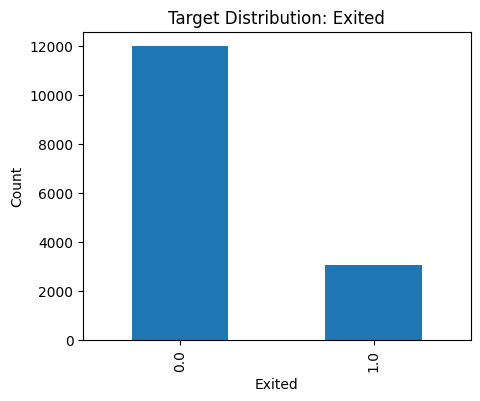

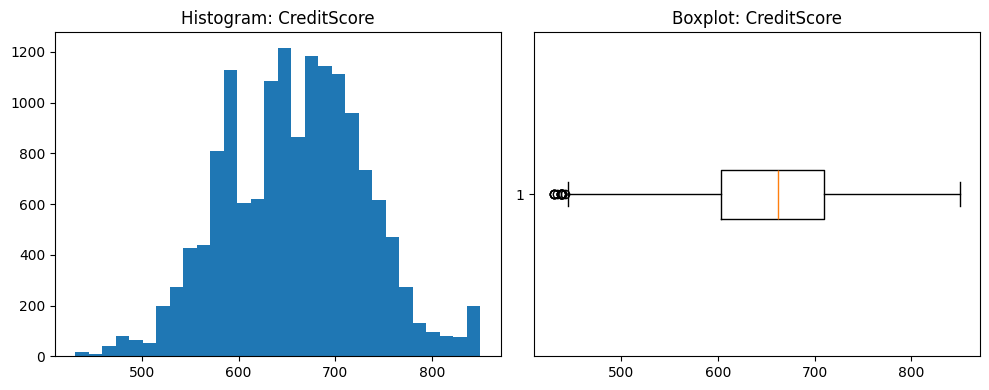

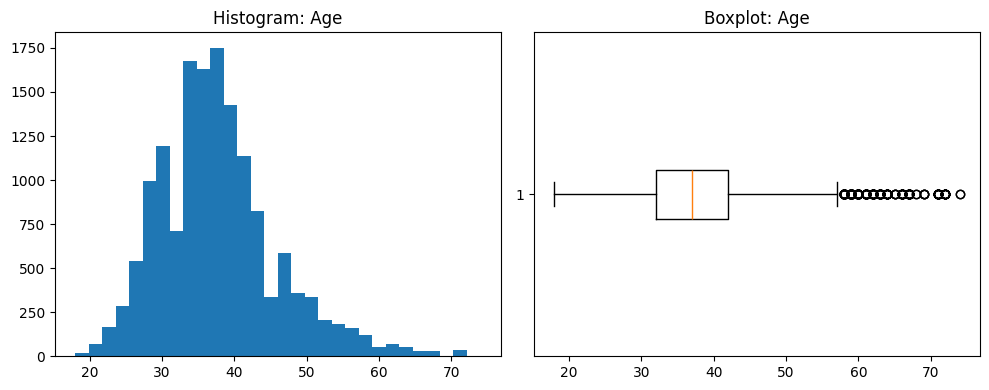

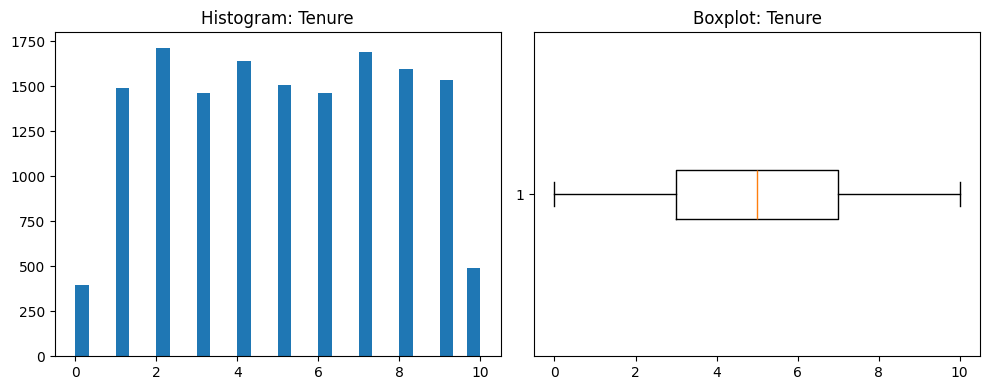

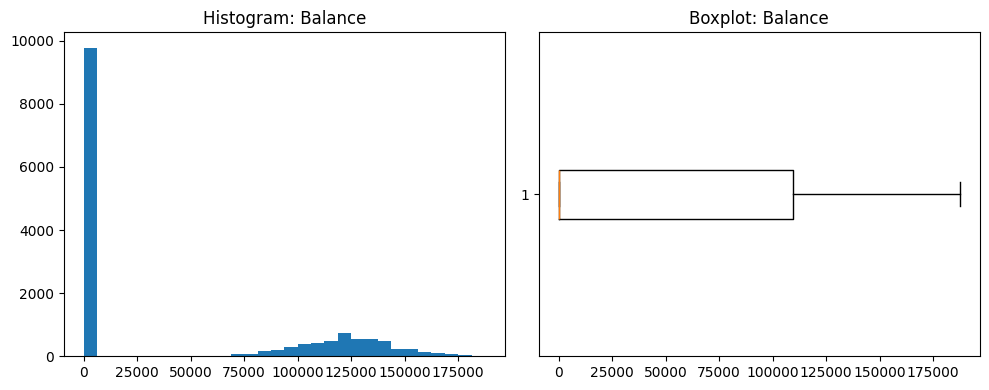

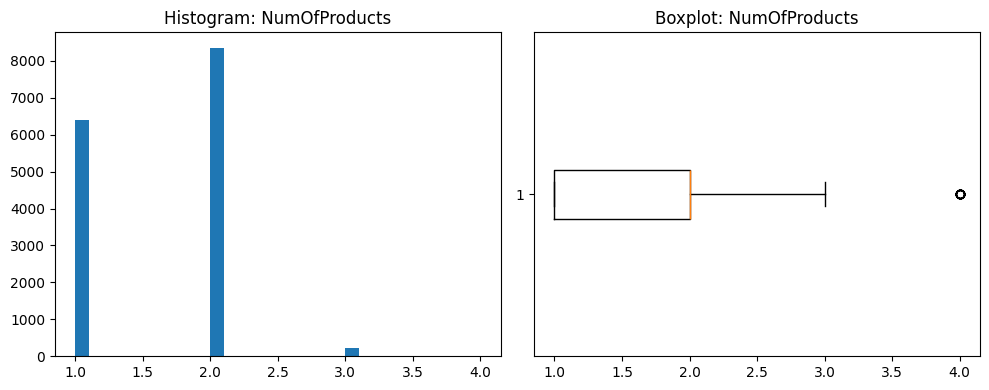

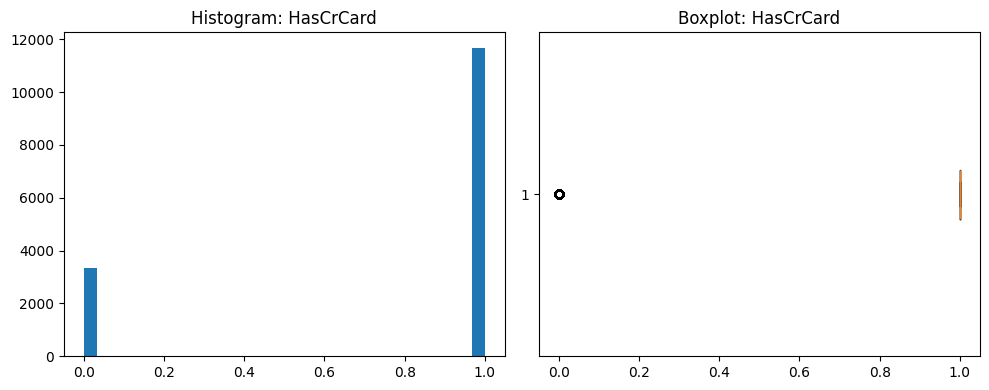

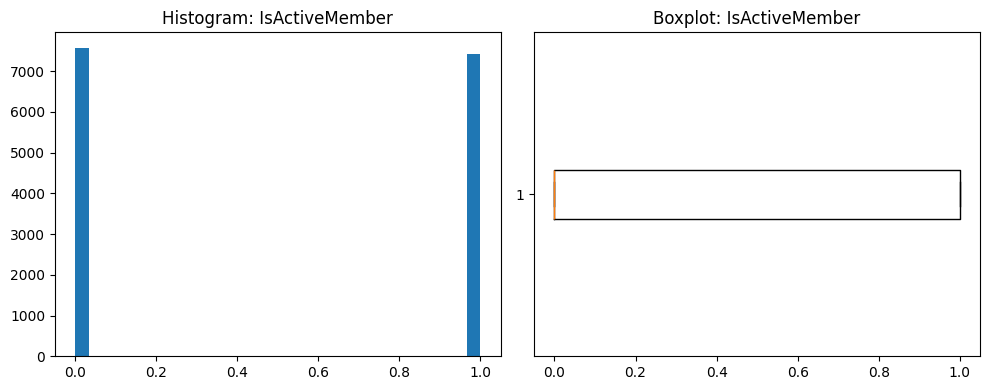

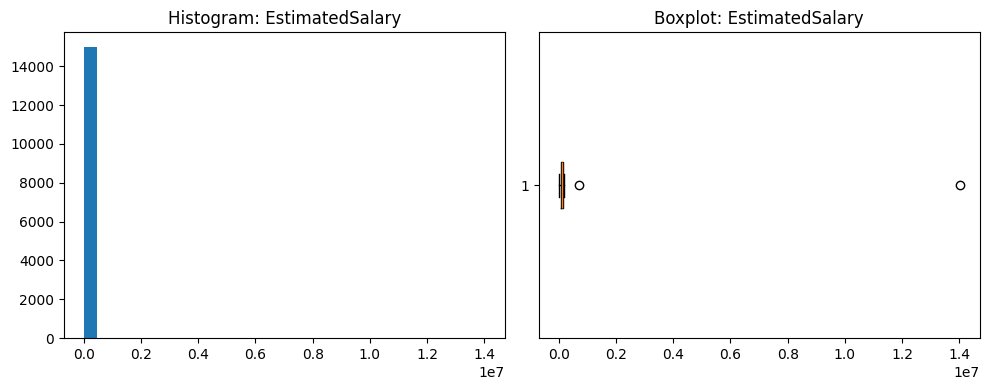

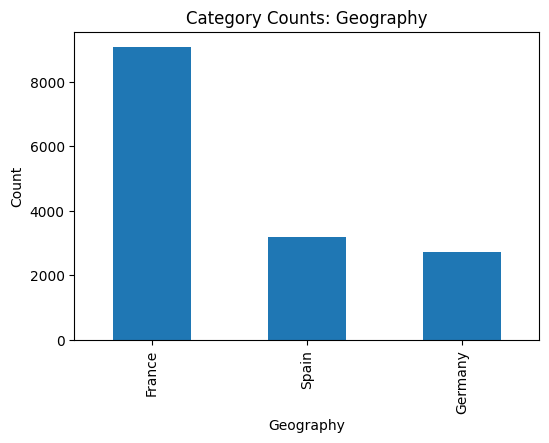

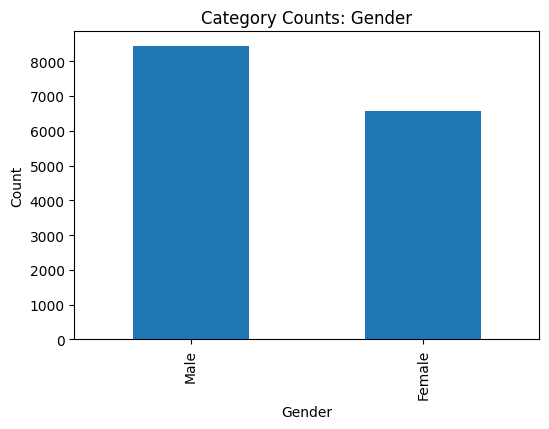

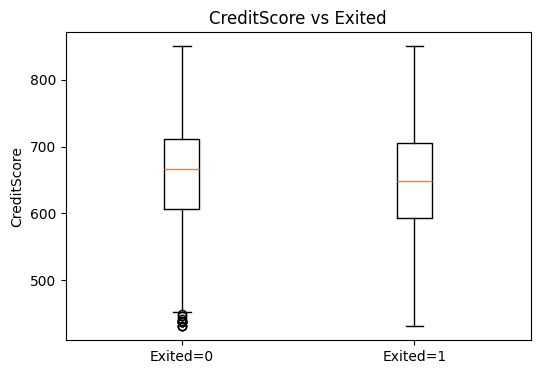

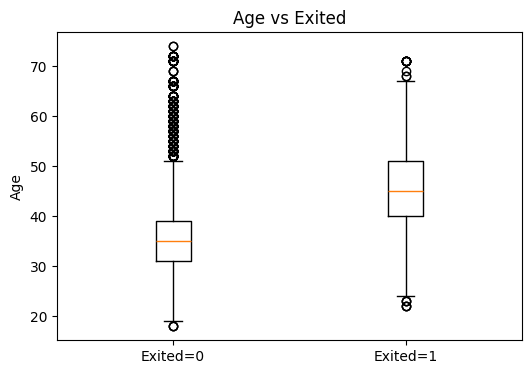

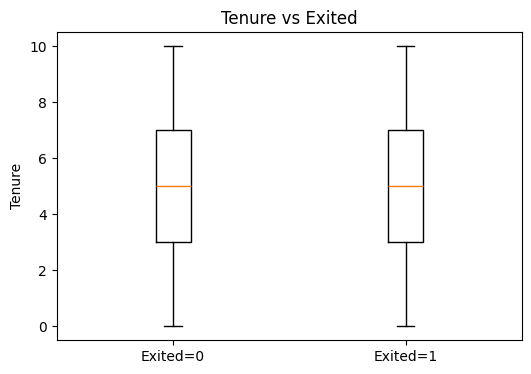

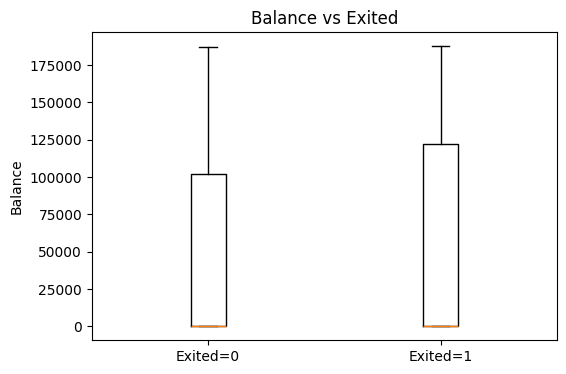

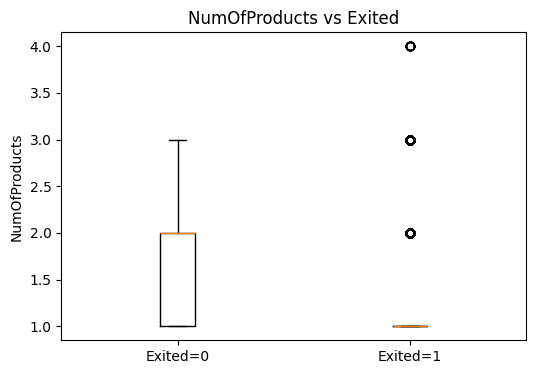

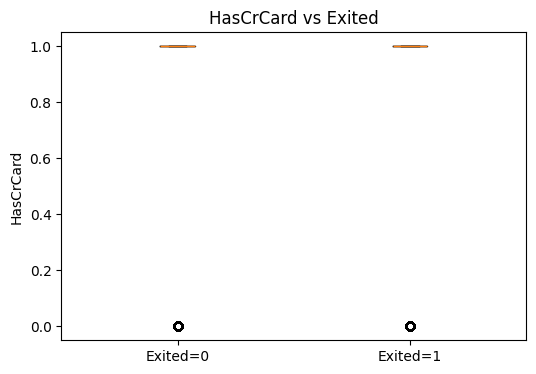

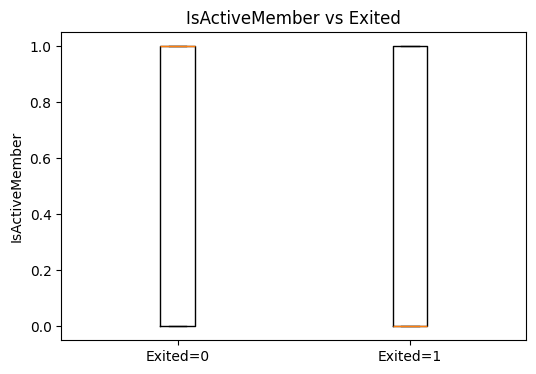

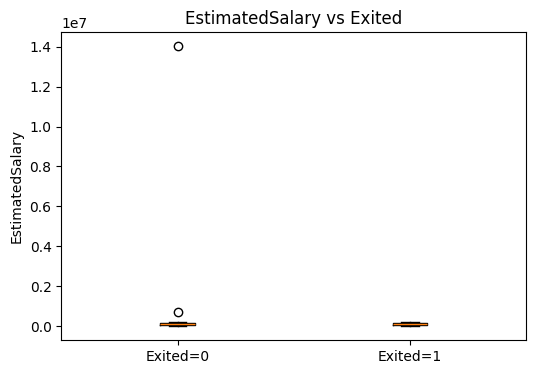

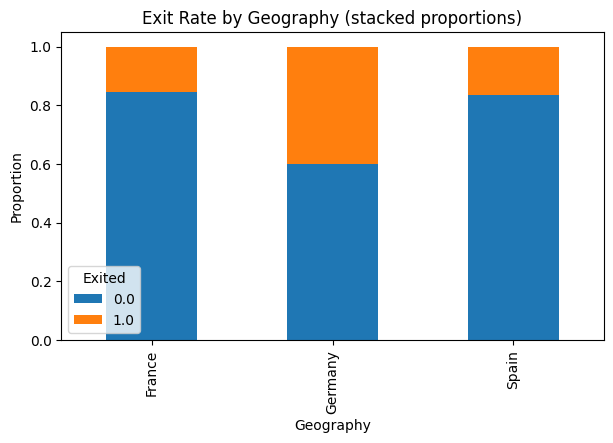

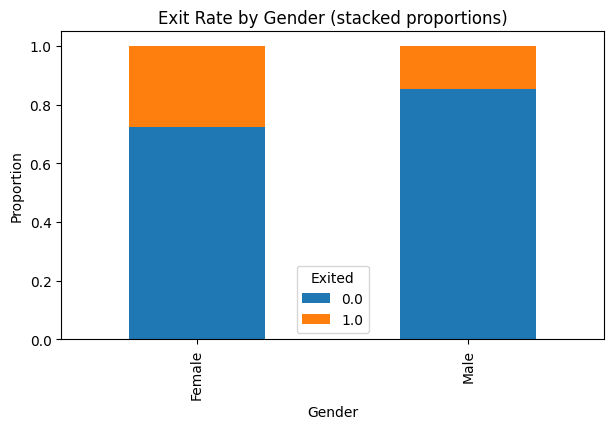

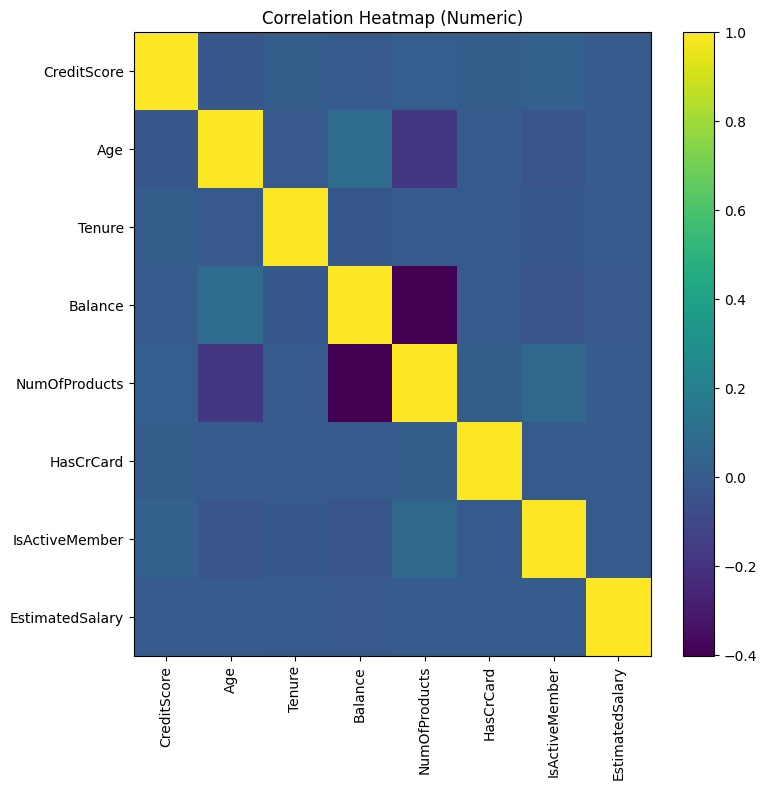

,mutual_info
Age,0.134495
NumOfProducts,0.123029
IsActiveMember,0.026473
Geography,0.021422
Balance,0.019573
Gender,0.015210
HasCrCard,0.007405
EstimatedSalary,0.007270
CreditScore,0.004730
Tenure,0.001855


In [37]:

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

print(f'Numeric columns: {len(numeric_cols)} | Categorical columns: {len(categorical_cols)}')

# Target distribution
fig = plt.figure(figsize=(5,4))
class_counts['count'].plot(kind='bar')
plt.title('Target Distribution: Exited')
plt.ylabel('Count'); plt.xlabel('Exited'); plt.show()

# Univariate numeric
for col in numeric_cols:
    fig = plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.hist(X[col].dropna(), bins=30); plt.title(f'Histogram: {col}')
    plt.subplot(1,2,2); plt.boxplot(X[col].dropna(), vert=False); plt.title(f'Boxplot: {col}')
    plt.tight_layout(); plt.show()

# Categorical bar charts
for col in categorical_cols:
    fig = plt.figure(figsize=(6,4))
    X[col].value_counts(dropna=False).plot(kind='bar')
    plt.title(f'Category Counts: {col}'); plt.ylabel('Count'); plt.show()

# Bivariate numeric vs target
for col in numeric_cols:
    fig = plt.figure(figsize=(6,4))
    data0 = X.loc[y==0, col].dropna(); data1 = X.loc[y==1, col].dropna()
    plt.boxplot([data0, data1], labels=['Exited=0','Exited=1'])
    plt.title(f'{col} vs Exited'); plt.ylabel(col); plt.show()

# Bivariate categorical vs target
for col in categorical_cols:
    ct = pd.crosstab(X[col], y, normalize='index')
    (ct[[0,1]] if 0 in ct.columns and 1 in ct.columns else ct).plot(kind='bar', stacked=True, figsize=(7,4))
    plt.title(f'Exit Rate by {col} (stacked proportions)'); plt.ylabel('Proportion'); plt.legend(title='Exited'); plt.show()

# Correlation heatmap
if len(numeric_cols) >= 2:
    corr = X[numeric_cols].corr()
    plt.figure(figsize=(min(12, 0.5*len(numeric_cols)+4), min(10, 0.5*len(numeric_cols)+4)))
    plt.imshow(corr, aspect='auto'); plt.colorbar(); plt.title('Correlation Heatmap (Numeric)')
    plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
    plt.yticks(range(len(numeric_cols)), numeric_cols); plt.tight_layout(); plt.show()

    # High-corr pairs
    pairs = []
    for i in range(len(numeric_cols)):
        for j in range(i+1, len(numeric_cols)):
            r = corr.iloc[i,j]
            if abs(r) >= 0.8: pairs.append((numeric_cols[i], numeric_cols[j], r))
    if pairs: display(pd.DataFrame(pairs, columns=['feature_1','feature_2','corr']).sort_values('corr', ascending=False))

# Mutual information (best-effort)
try:
    from sklearn.feature_selection import mutual_info_classif
    mi_X = X.copy()
    for c in categorical_cols:
        mi_X[c] = mi_X[c].astype('category').cat.codes
    mi_X = mi_X.fillna(mi_X.median(numeric_only=True)).fillna(0)
    mi_scores = pd.Series(mutual_info_classif(mi_X, y, random_state=SEED), index=mi_X.columns).sort_values(ascending=False)
    display(mi_scores.to_frame('mutual_info').head(20))
except Exception as e:
    print('Mutual information step skipped due to:', e)


## Step 3 — Data Preparation and Feature Engineering



This section builds a **reproducible preprocessing pipeline** that prepares raw features for modeling and documents the transformation results. It standardizes numeric variables, encodes categoricals with a cross-version–safe One-Hot Encoder, and produces a before/after audit to verify correctness and prevent leakage into cross-validation.

**What can we potentially do here?**

* **Robust One-Hot Encoding:** Uses a compatibility wrapper (`build_ohe`) to support both `sparse_output=False` (new sklearn) and `sparse=False` (older sklearn); applies `drop='first'` to avoid the dummy-variable trap.
* **Numeric pipeline:** Median imputation → standardization (`StandardScaler`).
* **Categorical pipeline:** Most-frequent imputation → one-hot encoding (with unknown categories safely ignored).
* **Unified transformer:** `ColumnTransformer` combines numeric and categorical pipelines; non-selected columns are dropped.
* **Feature name tracing:** Derives **post-transform feature names** (including expanded one-hot columns) for transparent modeling and diagnostics.
* **Before/After audit (no leakage):** Clones and fits the preprocessor **only for reporting**, then:

  * Reports input shape, dtype mix, and missing-value profile.
  * Shows transformed matrix shape and total engineered feature count.
  * Audits each categorical: total levels, encoded columns kept, and the **dropped baseline**.
  * Optionally previews the transformed design matrix (first rows) as a DataFrame.

**Why it matters?**

* Ensures **consistent, CV-safe** preprocessing across all models.
* Prevents **data leakage** by separating reporting from the training pipeline.
* Delivers **traceability** of engineered features (names, counts, baselines).
* Creates a **clean, model-ready design matrix** that downstream estimators can consume without additional wrangling.

> Note: At this stage, “feature engineering” focuses on **systematic transformations** (imputation, scaling, encoding). Domain-specific feature creation (e.g., interactions, ratios, buckets) can be added later as an extension to this pipeline.

> **Data leakage** occurs when information from outside the training process—especially from the validation or test sets—unintentionally influences model training. This leads to overly optimistic performance estimates that do not generalize to new data. In preprocessing pipelines, leakage often happens when imputers, scalers, or encoders are fit on the full dataset before cross-validation, allowing statistical properties of the validation folds (e.g., mean, median, category levels) to “leak” into the model. To prevent this, transformations must be fit **only on the training portion of each fold** and then applied to the corresponding validation data. In this section, the code avoids leakage by cloning and fitting the preprocessor strictly for reporting purposes, while the actual training pipeline applies the same steps safely within cross-validation.



### **AI-Prompt:**

Design a Python workflow for **data preparation and feature engineering** in a binary classification project. The workflow must be structured as a reusable pipeline and include the following capabilities:

1. **Numeric feature handling**

   * Impute missing values using the median.
   * Standardize features so they are on a comparable scale.

2. **Categorical feature handling**

   * Impute missing values with the most frequent category.
   * Apply one-hot encoding, dropping one baseline level per variable to avoid the dummy-variable trap.
   * Ensure compatibility across different versions of scikit-learn (i.e., handle environments where encoder parameters may differ).

3. **Unified preprocessing pipeline**

   * Use a column transformer to combine numeric and categorical pipelines.
   * Drop any columns not explicitly included in the transformations.

4. **Feature name tracking**

   * Extract and report the transformed feature names (important for one-hot encoded variables that expand into multiple columns).

5. **Before/After overview function**

   * Print dataset shape, number of numeric and categorical features, data type counts, and missing value summary before preprocessing.
   * Apply a cloned version of the pipeline (for reporting only) to show the transformed dataset shape and feature count after preprocessing.
   * Provide an audit of categorical encoding, including total levels, number of encoded columns, and which baseline was dropped.
   * Display a preview of the transformed design matrix (first few rows) with feature names.
   * Ensure this audit does not cause data leakage into model training or cross-validation.

6. **User friendliness**

   * Assume I am not familiar with Python.
   * Provide **clear, plain-English comments** that explain each step, why it is needed, and how to interpret the output.
   * Include informative printouts for transparency.

**Goal:** Produce a single, notebook-ready script that prepares numeric and categorical features for machine learning in a robust, transparent, and reproducible way, while preventing data leakage and ensuring interpretability of engineered features.


In [38]:
from inspect import signature
from sklearn.base import clone

# Build OneHotEncoder with cross-version compatibility
def build_ohe():
    try:
        # Newer scikit-learn uses 'sparse_output'
        # drop='first' removes one baseline per categorical (avoids dummy-variable trap)
        return OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)
    except TypeError:
        # Older versions use 'sparse'
        return OneHotEncoder(handle_unknown='ignore', drop='first', sparse=False)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', build_ohe())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop'
)

def get_transformed_feature_names(preprocessor: ColumnTransformer) -> List[str]:
    feature_names = []
    for name, trans, cols in preprocessor.transformers_:
        if name == 'remainder' and trans == 'drop':
            continue
        if hasattr(trans, 'named_steps') and 'onehot' in trans.named_steps:
            ohe = trans.named_steps['onehot']
            feature_names.extend(ohe.get_feature_names_out(cols).tolist())
        elif hasattr(trans, 'get_feature_names_out'):
            feature_names.extend(trans.get_feature_names_out(cols).tolist())
        else:
            feature_names.extend(list(cols))
    return feature_names

def overview_before_after(
    X: pd.DataFrame,
    preprocessor: ColumnTransformer,
    numeric_cols: List[str],
    categorical_cols: List[str],
    sample_rows: int = 5
):
    """
    Prints a BEFORE/AFTER snapshot of the dataset around the preprocessing step.
    Uses a *cloned* preprocessor fitted only for reporting, so it does not affect
    the training pipeline used later (no leakage into CV).
    """
    print("=== BEFORE (raw features passed to the pipeline) ===")
    print(f"Shape: {X.shape[0]} rows × {X.shape[1]} columns")
    print(f"Numeric columns: {len(numeric_cols)} | Categorical columns: {len(categorical_cols)}")
    print("\nDtype counts:")
    print(X.dtypes.astype(str).value_counts().to_string())
    total_na = int(X.isna().sum().sum())
    print(f"\nTotal missing values: {total_na}")
    print("Top-10 columns by missingness:")
    display(X.isna().sum().sort_values(ascending=False).head(10))

    # Fit a cloned preprocessor for inspection only
    pp = clone(preprocessor)
    pp.fit(X)

    # Transformed matrix and names
    X_t = pp.transform(X)
    feat_names = get_transformed_feature_names(pp)

    print("\n=== AFTER (transformed design matrix) ===")
    print(f"Transformed shape: {X_t.shape[0]} rows × {X_t.shape[1]} columns")
    print(f"Transformed feature count: {len(feat_names)}")

    # OneHot audit (levels, kept columns, dropped baseline)
    try:
        ohe = pp.named_transformers_['cat'].named_steps['onehot']
        cats = ohe.categories_
        drops = getattr(ohe, 'drop_idx_', None)
        print("\nOneHot summary per categorical:")
        for i, col in enumerate(categorical_cols):
            levels = cats[i]
            k = len(levels)
            # Number encoded after drop policy
            if getattr(ohe, 'drop', None) in ('first', 'if_binary'):
                kept = k - 1 if k > 1 else 0
            elif getattr(ohe, 'drop', None) is None:
                kept = k
            else:
                kept = k - 1  # generic fallback
            dropped_label = None
            if drops is not None and i < len(drops):
                di = drops[i]
                if di is not None and di != -1:
                    dropped_label = levels[di]
            print(f"  - {col}: levels={k}, encoded_columns={kept}, baseline_dropped={dropped_label}")
    except Exception as e:
        print("OHE audit skipped:", e)

    # Preview transformed design matrix as DataFrame
    try:
        X_t_df = pd.DataFrame(X_t, columns=feat_names).iloc[:sample_rows]
        print(f"\nPreview of transformed matrix (first {sample_rows} rows):")
        display(X_t_df)
    except Exception as e:
        print("Preview skipped:", e)

    return pp, feat_names  # return fitted clone & names in case you want to reuse for reporting

print('Preprocessor defined (OHE compatibility ensured).')

# Generate BEFORE/AFTER overview now (for reporting only; training still uses CV-safe pipeline)
_ = overview_before_after(X, preprocessor, numeric_cols, categorical_cols, sample_rows=5)


Preprocessor defined (OHE compatibility ensured).
=== BEFORE (raw features passed to the pipeline) ===
Shape: 15000 rows × 10 columns
Numeric columns: 8 | Categorical columns: 2

Dtype counts:
float64    8
object     2

Total missing values: 0
Top-10 columns by missingness:


,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0



=== AFTER (transformed design matrix) ===
Transformed shape: 15000 rows × 11 columns
Transformed feature count: 11

OneHot summary per categorical:
  - Geography: levels=3, encoded_columns=2, baseline_dropped=France
  - Gender: levels=2, encoded_columns=1, baseline_dropped=Female

Preview of transformed matrix (first 5 rows):


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,1.090043,0.159429,-0.373152,-0.712562,0.772595,0.533560,1.009781,0.464210,0.0,1.0,1.0
1,-3.007922,0.037092,-0.732505,1.040200,-1.117931,0.533560,1.009781,-0.099103,0.0,0.0,1.0
2,-2.578744,-0.085244,0.704907,0.842273,-1.117931,0.533560,1.009781,0.110720,0.0,1.0,1.0
3,-0.917406,-0.574590,-0.373152,-0.712562,0.772595,-1.874203,-0.990314,-0.132390,0.0,1.0,1.0
4,1.519222,-0.207581,0.704907,-0.712562,0.772595,0.533560,1.009781,0.347714,0.0,0.0,1.0


## Step 4 — Basic Model

In this step, we fit a **baseline predictive model** using **logistic regression** and evaluate its performance with rigorous cross-validation and bootstrap confidence intervals. The purpose is to establish a benchmark model that is simple, interpretable, and statistically well-documented before moving to more complex methods.

**Key components of this step**:

* **Cross-validation with stratification**: A 5-fold stratified cross-validation ensures that class proportions are preserved in each fold, providing a reliable estimate of model performance.

* **Out-of-Fold (OOF) predictions**: Predictions for all observations are generated from models trained without those observations, allowing us to estimate performance as if on unseen data.

* **Evaluation metrics**: For each fold and overall, we compute:

  * **Accuracy** and **misclassification error** (1 – accuracy).

  * **ROC AUC** (area under the receiver operating characteristic curve) as a robust measure of ranking ability.

* **Bootstrap confidence intervals**: Using stratified bootstrap resampling, we compute 95% confidence intervals for both AUC and error rates, giving a sense of uncertainty around the performance metrics.

* **Fold-level summary**: Reports mean and standard deviation of AUC and error across folds, as well as a detailed per-fold metrics table.

* **Pipeline integration**: The preprocessing steps defined earlier (imputation, scaling, one-hot encoding) are seamlessly integrated into the logistic regression model through a scikit-learn pipeline, ensuring that all data transformations are applied consistently during training and evaluation.

This structured evaluation provides a **transparent and statistically sound baseline** against which more advanced models can later be compared.



### **AI-Prompt:**

Create a Python workflow for building and evaluating a **baseline predictive model** using logistic regression. The workflow should be implemented with a reproducible machine learning pipeline and include the following capabilities:

1. **Pipeline integration**

   * Incorporate the preprocessing steps already defined (numeric imputation + scaling, categorical imputation + one-hot encoding).
   * Ensure transformations are applied consistently during both training and validation.

2. **Model training**

   * Use logistic regression as the classifier.
   * Handle potential class imbalance by applying appropriate weighting.

3. **Cross-validation**

   * Apply stratified k-fold cross-validation (e.g., 5 folds) to maintain class proportions in each split.
   * Generate **out-of-fold (OOF) predictions** for every observation to provide unbiased performance estimates.

4. **Evaluation metrics**

   * For each fold and overall, compute **accuracy**, **misclassification error**, and **ROC AUC**.
   * Report both per-fold metrics and aggregated summaries (mean and standard deviation across folds).

5. **Uncertainty estimation**

   * Use **bootstrap resampling** (stratified by class) to calculate 95% confidence intervals for AUC and misclassification error.

6. **Outputs and reporting**

   * Print overall OOF metrics (AUC, accuracy, error).
   * Display bootstrap confidence intervals.
   * Provide a summary of fold-level metrics and a formatted table of per-fold results.

**Additional requirements**

* Assume I am not familiar with Python—include **step-by-step comments in plain English** explaining what each part of the workflow does, why it is necessary, and how to interpret the results.
* Use clear, beginner-friendly printouts to highlight the main results.

**Goal:** Deliver a notebook-ready, transparent, and statistically sound baseline evaluation of logistic regression that can serve as a benchmark for comparing more advanced models later.


In [39]:
# --- Step 4: Full logistic regression with CV + stratified bootstrap CIs (adds fold-wise avg AUC) ---
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score

def stratified_bootstrap_metrics(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    n_boot: int = 2000,
    seed: int = 474
) -> Dict[str, Tuple[float, float]]:
    """Percentile 95% CIs for AUC and misclassification error via stratified bootstraps."""
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)

    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]
    n_pos, n_neg = len(pos_idx), len(neg_idx)

    aucs, errs = [], []
    for _ in range(n_boot):
        samp_pos = rng.choice(pos_idx, size=n_pos, replace=True)
        samp_neg = rng.choice(neg_idx, size=n_neg, replace=True)
        idx = np.concatenate([samp_pos, samp_neg])
        yt = y_true[idx]; yp = y_prob[idx]

        try:
            aucs.append(roc_auc_score(yt, yp))
        except Exception:
            continue

        preds = (yp >= 0.5).astype(int)
        errs.append(1.0 - accuracy_score(yt, preds))

    def ci(a: List[float]) -> Tuple[float, float]:
        a = np.asarray(a, dtype=float)
        return (np.nanpercentile(a, 2.5), np.nanpercentile(a, 97.5))
    return {"auc_ci": ci(aucs), "error_ci": ci(errs)}

def evaluate_pipeline_cv(
    pipeline: Pipeline,
    X: pd.DataFrame,
    y: pd.Series,
    cv_splits: int = 5,
    seed: int = 42
) -> Dict:
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=seed)

    y = pd.Series(y).astype(int)
    oof_prob = np.zeros(len(y), dtype=float)
    oof_true = y.to_numpy(dtype=int)

    fold_metrics: List[Dict[str, float]] = []
    for fold, (tr, va) in enumerate(skf.split(X, y), start=1):
        X_tr, X_va = X.iloc[tr], X.iloc[va]
        y_tr, y_va = y.iloc[tr], y.iloc[va]

        pipe = clone(pipeline)
        pipe.fit(X_tr, y_tr)

        prob = pipe.predict_proba(X_va)[:, 1]
        oof_prob[va] = prob

        preds = (prob >= 0.5).astype(int)
        acc = accuracy_score(y_va, preds)
        err = 1.0 - acc
        auc = roc_auc_score(y_va, prob)

        fold_metrics.append(
            {"fold": fold, "accuracy": acc, "misclassification_error": err, "roc_auc": auc}
        )

    # Overall metrics from concatenated OOF predictions
    overall_auc = roc_auc_score(oof_true, oof_prob)
    overall_acc = accuracy_score(oof_true, (oof_prob >= 0.5).astype(int))
    overall_err = 1.0 - overall_acc

    # NEW: fold-wise averages
    fold_auc_values = np.array([m["roc_auc"] for m in fold_metrics], dtype=float)
    fold_err_values = np.array([m["misclassification_error"] for m in fold_metrics], dtype=float)
    fold_summary = {
        "roc_auc_mean": float(np.mean(fold_auc_values)),
        "roc_auc_std": float(np.std(fold_auc_values, ddof=1)) if len(fold_auc_values) > 1 else 0.0,
        "error_mean": float(np.mean(fold_err_values)),
        "error_std": float(np.std(fold_err_values, ddof=1)) if len(fold_err_values) > 1 else 0.0,
    }

    cis = stratified_bootstrap_metrics(oof_true, oof_prob, n_boot=2000, seed=seed)

    return {
        "oof_true": oof_true,
        "oof_prob": oof_prob,
        "overall": {
            "roc_auc": overall_auc,
            "accuracy": overall_acc,
            "misclassification_error": overall_err,
        },
        "bootstrap_ci": cis,
        "fold_metrics": fold_metrics,
        "fold_summary": fold_summary,
    }

log_reg = LogisticRegression(
    max_iter=1000, class_weight="balanced", solver="lbfgs", random_state=SEED
)
full_pipeline = Pipeline(steps=[("preprocess", preprocessor), ("clf", log_reg)])

results_full = evaluate_pipeline_cv(full_pipeline, X, y, cv_splits=5, seed=SEED)

print("Full model results:")
print("Out-of-fold predictions (OOF) AUC:", round(results_full["overall"]["roc_auc"], 4))
print("Out-of-fold predictions (OOF) Error:", round(results_full["overall"]["misclassification_error"], 4))
print("AUC 95% CI:", results_full["bootstrap_ci"]["auc_ci"])
print("Error 95% CI:", results_full["bootstrap_ci"]["error_ci"])

# Report average fold AUC (and std)
print("Mean CV AUC (across folds):", round(results_full["fold_summary"]["roc_auc_mean"], 4))
print("Std CV AUC (across folds):", round(results_full["fold_summary"]["roc_auc_std"], 4))

# Per-fold metrics table
pd.DataFrame(results_full["fold_metrics"]).style.format(
    {"accuracy": "{:.4f}", "misclassification_error": "{:.4f}", "roc_auc": "{:.4f}"}
)


Full model results:
Out-of-fold predictions (OOF) AUC: 0.8825
Out-of-fold predictions (OOF) Error: 0.1848
AUC 95% CI: (np.float64(0.8753042532807621), np.float64(0.8892975168745592))
Error 95% CI: (np.float64(0.17866499999999996), np.float64(0.19106666666666672))
Mean CV AUC (across folds): 0.8826
Std CV AUC (across folds): 0.0071


,fold,accuracy,misclassification_error,roc_auc
0,1,0.8190,0.1810,0.8835
1,2,0.8230,0.1770,0.8901
2,3,0.8037,0.1963,0.8837
3,4,0.8167,0.1833,0.8849
4,5,0.8137,0.1863,0.8708


## Step 5 — More Complex Model

Building on the baseline logistic regression, this step explores **more flexible predictive models** that can capture non-linear relationships, interactions between variables, and complex decision boundaries. The goal is to assess whether more advanced algorithms can improve predictive performance beyond the benchmark established in Step 4.

**Key components of this step**:

* **Model selection**: Introduce and train models with greater representational power, such as decision trees, random forests, gradient boosting (e.g., XGBoost, LightGBM), or regularized regression methods (LASSO, Ridge, Elastic Net).
* **Cross-validation evaluation**: Apply the same rigorous 5-fold stratified cross-validation procedure to ensure comparability with the baseline model.
* **Out-of-Fold (OOF) predictions**: Generate unbiased performance estimates by aggregating predictions from models trained without the corresponding observations.
* **Performance metrics**: Compute and compare accuracy, misclassification error, and ROC AUC for each model. Use per-fold results, overall metrics, and summary statistics (mean and standard deviation across folds).
* **Uncertainty estimation**: Extend evaluation with bootstrap confidence intervals for AUC and error, quantifying the reliability of improvements relative to the baseline.
* **Pipeline integration**: Ensure preprocessing (imputation, scaling, encoding) is consistently applied within each model’s pipeline, preventing leakage and preserving comparability.
* **Model comparison**: Present results side by side with the baseline, highlighting both performance gains and potential trade-offs (e.g., interpretability vs. accuracy).

This step provides a **systematic framework for testing more advanced algorithms** while maintaining the same statistical rigor, making it possible to judge whether added model complexity delivers meaningful improvements.



## Step 5.1: Forward stepwise feature selection

### **AI-Prompt:**

Design a Python workflow for performing **forward stepwise feature selection** in a binary classification project. The workflow should use logistic regression as the base model and follow these requirements:

1. **Baseline model**

   * Build a logistic regression classifier with reasonable defaults (e.g., balanced class weights, sufficient iterations, reproducible random seed).
   * Integrate preprocessing (numeric imputation + scaling, categorical imputation + one-hot encoding) into a scikit-learn pipeline.
   * Fit the baseline pipeline to confirm feature compatibility and extract the full list of transformed feature names after preprocessing.

2. **Sequential Feature Selection (SFS)**

   * Apply forward stepwise selection using logistic regression as the estimator.
   * Use cross-validation (e.g., 5 folds) and **ROC AUC** as the evaluation metric to decide which features to keep.
   * Automatically determine the optimal number of features.
   * Record the indices and names of the selected features.

3. **Refined pipeline**

   * Build a new pipeline that applies preprocessing, then restricts the dataset to the selected features, and finally fits logistic regression.
   * Ensure the pipeline can be reused seamlessly for training, validation, and later prediction.

4. **Model evaluation**

   * Re-evaluate the refined pipeline using cross-validation.
   * Generate **out-of-fold (OOF) predictions** and compute:

     * Accuracy
     * Misclassification error
     * ROC AUC
   * Summarize fold-level results (mean and standard deviation of AUC across folds).
   * Compute **95% bootstrap confidence intervals** for AUC and error to quantify uncertainty.

5. **Reporting**

   * Print the number of features selected and list the top selected feature names.
   * Report OOF AUC and error, along with their bootstrap confidence intervals.
   * Report mean and standard deviation of fold-level AUC.
   * Display a formatted per-fold metrics table for accuracy, error, and AUC.

**Additional requirements:**

* Assume I am not familiar with Python. Include **clear, plain-English comments** at every step to explain what is happening, why it is important, and how to interpret the results.
* Output should be a single, notebook-ready workflow that is reproducible and easy to extend.

**Goal:** Produce a transparent and statistically rigorous stepwise feature selection process that demonstrates how model performance changes when using only the most predictive subset of features.



In [40]:

base_clf = LogisticRegression(max_iter=1000, class_weight='balanced', solver='lbfgs', random_state=SEED)

_tmp = Pipeline(steps=[('preprocess', preprocessor), ('clf', base_clf)])
_tmp.fit(X, y)
transformed_feature_names = get_transformed_feature_names(_tmp.named_steps['preprocess'])

sfs = SequentialFeatureSelector(
    base_clf, n_features_to_select='auto', direction='forward',
    scoring='roc_auc', cv=5, n_jobs=-1
)

pipe_for_sfs = Pipeline(steps=[('preprocess', preprocessor), ('sfs', sfs), ('clf', base_clf)])
pipe_for_sfs.fit(X, y)

sfs_step = pipe_for_sfs.named_steps['sfs']
selected_mask = sfs_step.get_support()
selected_idx = np.where(selected_mask)[0].tolist()

if len(transformed_feature_names) == len(selected_mask):
    selected_feature_names = [transformed_feature_names[i] for i in selected_idx]
else:
    selected_feature_names = [f'feat_{i}' for i in selected_idx]

print(f'Selected {len(selected_feature_names)} transformed features via forward SFS.')
selected_feature_names[:20]

def column_index_selector(X_arr: np.ndarray, indices: List[int]) -> np.ndarray:
    return X_arr[:, indices]

from sklearn.preprocessing import FunctionTransformer
selector = FunctionTransformer(column_index_selector, kw_args={'indices': selected_idx})

refined_pipeline = Pipeline(steps=[('preprocess', preprocessor),
                                   ('select', selector),
                                   ('clf', base_clf)])

results_stepwise = evaluate_pipeline_cv(refined_pipeline, X, y, cv_splits=5, seed=SEED)

# --- Reporting: OOF AUC, OOF Error, and fold-wise mean/std AUC ---
print('Forward-stepwise model results:')
print('Out-of-fold predictions (OOF) AUC:', round(results_stepwise['overall']['roc_auc'], 4))
print('Out-of-fold predictions (OOF) Error:', round(results_stepwise['overall']['misclassification_error'], 4))
print('AUC 95% CI:', results_stepwise['bootstrap_ci']['auc_ci'])
print('Error 95% CI:', results_stepwise['bootstrap_ci']['error_ci'])

# If evaluate_pipeline_cv returns fold_summary, use it; otherwise compute from fold_metrics
if 'fold_summary' in results_stepwise:
    mean_cv_auc = results_stepwise['fold_summary']['roc_auc_mean']
    std_cv_auc  = results_stepwise['fold_summary']['roc_auc_std']
else:
    _auc_vals = np.array([m['roc_auc'] for m in results_stepwise['fold_metrics']], dtype=float)
    mean_cv_auc = float(np.mean(_auc_vals))
    std_cv_auc  = float(np.std(_auc_vals, ddof=1)) if len(_auc_vals) > 1 else 0.0

print('Mean CV AUC (across folds):', round(mean_cv_auc, 4))
print('Std CV AUC (across folds):', round(std_cv_auc, 4))

# Per-fold table
pd.DataFrame(results_stepwise['fold_metrics']).style.format(
    {'accuracy': '{:.4f}', 'misclassification_error': '{:.4f}', 'roc_auc': '{:.4f}'}
)


Selected 5 transformed features via forward SFS.
Forward-stepwise model results:
Out-of-fold predictions (OOF) AUC: 0.8809
Out-of-fold predictions (OOF) Error: 0.1891
AUC 95% CI: (np.float64(0.8740104749678277), np.float64(0.8875955293559101))
Error 95% CI: (np.float64(0.1825983333333333), np.float64(0.19540000000000002))
Mean CV AUC (across folds): 0.881
Std CV AUC (across folds): 0.0063


,fold,accuracy,misclassification_error,roc_auc
0,1,0.8177,0.1823,0.8828
1,2,0.8177,0.1823,0.8877
2,3,0.7977,0.2023,0.8823
3,4,0.8137,0.1863,0.8817
4,5,0.8080,0.1920,0.8706


In [27]:
pipe_for_sfs

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Geography', 'Gender'])])),
                ('sfs',
                 SequentialFeatureSelector(estimator=LogisticRegression(class_weight='balanced',
                                                                        max_iter=1000,
                                                                        random_state=474),
                                           n_jobs=-1, scoring='roc_auc')),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=474))])

## Step 5.2: Lasso Regression



### **AI-Prompt:**

Create a Python workflow to tune and evaluate a **LASSO (L1-penalized) logistic regression** for a binary classification task. The workflow should be **pipeline-based**, reproducible, and beginner-friendly, with clear comments explaining every step and why it matters.

**Requirements**

1. **Setup & Reproducibility**

   * Assume a preexisting preprocessing pipeline (numeric imputation+scaling; categorical imputation+one-hot) and training data `X, y`.
   * Use a fixed random seed throughout.
   * Use class weighting to address potential imbalance.

2. **Regularization grid**

   * Define a logarithmic grid of **λ (lambda)** values spanning several orders of magnitude.
   * Recall that scikit-learn’s logistic regression uses **C = 1/λ** (larger C ⇒ weaker regularization).
   * For each λ, configure an **L1-penalized** logistic regression with an appropriate solver and sufficient iterations.

3. **Cross-validated evaluation per λ**

   * Wrap model + preprocessing in a single pipeline.
   * Run **stratified k-fold cross-validation** (e.g., 5 folds).
   * Collect **out-of-fold (OOF)** predictions and compute:

     * **ROC AUC** (primary metric)
     * **Misclassification error** (1 − accuracy)
   * Also compute **fold-wise mean and standard deviation** of AUC.

4. **Uncertainty quantification**

   * For each λ, compute **95% bootstrap confidence intervals** (stratified by class) for **AUC** and **error**, using OOF predictions.

5. **Model sparsity diagnostic**

   * (Reporting only) Fit the L1 model on the **full training set** for each λ and record the **number of non-zero coefficients** to quantify sparsity.
   * Clarify in comments that this full-fit is **not** used for CV metrics (to avoid leakage) and is for interpretability reporting only.

6. **Results aggregation & selection**

   * Build a results table (DataFrame) with, for each λ: λ, C, OOF AUC, OOF error, their 95% CIs, mean CV AUC, std CV AUC, and non-zero coefficient count.
   * Select the **best λ** by **highest OOF AUC** (if tied, prefer the more regularized model).
   * Clearly print the chosen λ and C and summarize the corresponding metrics and CIs.

7. **Visualization**

   * Produce a **semilog plot** of performance vs. λ showing at least:

     * OOF AUC across λ
     * Mean CV AUC across λ
     * A vertical line marking the **best λ**
   * Use informative titles, axis labels, and a legend.

8. **Beginner-friendly guidance**

   * Add **plain-English comments** explaining:

     * What L1 regularization does (sparsity/feature selection).
     * Why we evaluate with OOF predictions and CV.
     * Why we use bootstrap CIs (quantify uncertainty).
     * How to read the results table and the λ vs. AUC plot.
   * End with a short textual summary interpreting the selected λ, expected generalization performance, and sparsity trade-offs.

**Output:**
A single, notebook-ready workflow that runs end-to-end, prints the results table and key metrics, shows the plot, and provides clear commentary suitable for readers new to Python and model tuning.


,lambda,C,oof_auc,oof_error,auc_ci_lower,auc_ci_upper,error_ci_lower,error_ci_upper,mean_cv_auc,std_cv_auc,nonzero_coef
0,0.000100,10000.000000,0.882543,0.184800,0.875319,0.889285,0.178533,0.191067,0.882633,0.007124,11
1,0.000228,4393.970561,0.882543,0.184800,0.875319,0.889285,0.178533,0.191067,0.882633,0.007124,11
2,0.000518,1930.697729,0.882543,0.184800,0.875319,0.889285,0.178533,0.191067,0.882633,0.007124,11
3,0.001179,848.342898,0.882543,0.184800,0.875319,0.889285,0.178533,0.191067,0.882633,0.007124,11
4,0.002683,372.759372,0.882543,0.184800,0.875319,0.889285,0.178533,0.191067,0.882633,0.007124,11
5,0.006105,163.789371,0.882543,0.184800,0.875319,0.889285,0.178533,0.191067,0.882634,0.007124,11
6,0.013895,71.968567,0.882543,0.184800,0.875319,0.889285,0.178533,0.191067,0.882633,0.007123,11
7,0.031623,31.622777,0.882543,0.184867,0.875320,0.889286,0.178798,0.191135,0.882633,0.007123,11
8,0.071969,13.894955,0.882544,0.184867,0.875320,0.889286,0.178798,0.191135,0.882634,0.007122,11
9,0.163789,6.105402,0.882544,0.184867,0.875320,0.889286,0.178798,0.191135,0.882635,0.007121,11


LASSO (L1) logistic model results [best over lambda grid]:
Best lambda (1/C): 10.0  | Best C: 0.1
Out-of-fold predictions (OOF) AUC: 0.8826
Out-of-fold predictions (OOF) Error: 0.1859
AUC 95% CI: (np.float64(0.8753808734818641), np.float64(0.8892849045723085))
Error 95% CI: (np.float64(0.17979999999999996), np.float64(0.19193499999999994))
Mean CV AUC (across folds): 0.8827
Std CV AUC (across folds): 0.0071


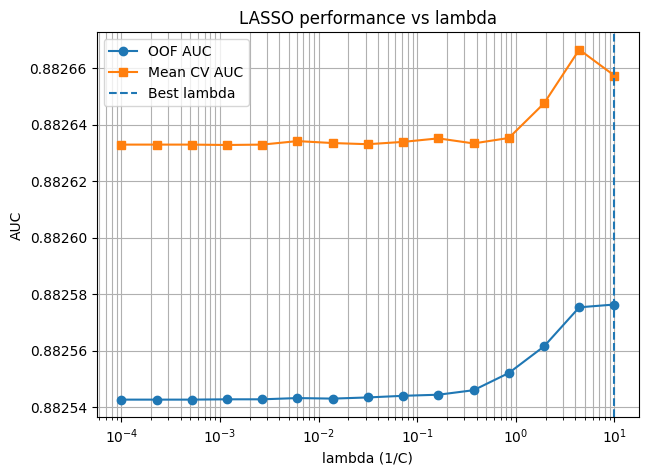

In [41]:
# --- LASSO Logistic Regression: grid over lambda with performance plots ---

from sklearn.linear_model import LogisticRegression
from sklearn.base import clone

# Grid of lambda (regularization strength). Note: scikit-learn uses C = 1 / lambda.
lam_grid = np.logspace(-4, 1, 15)  # adjust density/range as needed

grid_records = []
results_by_lam = {}

for lam in lam_grid:
    C_val = 1.0 / lam
    lasso_clf = LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=C_val,
        class_weight="balanced",
        max_iter=2000,
        random_state=SEED,
    )

    lasso_pipeline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("clf", lasso_clf)
    ])

    res = evaluate_pipeline_cv(lasso_pipeline, X, y, cv_splits=5, seed=SEED)

    # Mean/Std of per-fold AUC (fallback if not in res)
    if 'fold_summary' in res:
        mean_cv_auc = float(res['fold_summary']['roc_auc_mean'])
        std_cv_auc  = float(res['fold_summary']['roc_auc_std'])
    else:
        _auc_vals = np.array([m['roc_auc'] for m in res['fold_metrics']], dtype=float)
        mean_cv_auc = float(np.mean(_auc_vals))
        std_cv_auc  = float(np.std(_auc_vals, ddof=1)) if len(_auc_vals) > 1 else 0.0

    # Optional: number of non-zero coefficients when trained on all data (reporting only)
    nz_count = None
    try:
        _tmp = clone(lasso_pipeline).fit(X, y)
        coefs = _tmp.named_steps["clf"].coef_.ravel()
        nz_count = int(np.count_nonzero(coefs))
    except Exception:
        pass

    oof_auc  = float(res["overall"]["roc_auc"])
    oof_err  = float(res["overall"]["misclassification_error"])
    auc_ci   = res["bootstrap_ci"]["auc_ci"]
    err_ci   = res["bootstrap_ci"]["error_ci"]

    grid_records.append({
        "lambda": lam,
        "C": C_val,
        "oof_auc": oof_auc,
        "oof_error": oof_err,
        "auc_ci_lower": auc_ci[0],
        "auc_ci_upper": auc_ci[1],
        "error_ci_lower": err_ci[0],
        "error_ci_upper": err_ci[1],
        "mean_cv_auc": mean_cv_auc,
        "std_cv_auc": std_cv_auc,
        "nonzero_coef": nz_count
    })
    results_by_lam[lam] = res

# Results as DataFrame (sorted by lambda ascending)
lasso_grid_df = pd.DataFrame(grid_records).sort_values("lambda").reset_index(drop=True)
display(lasso_grid_df)

# Pick best lambda by highest OOF AUC (tie-breaker: smaller lambda -> stronger regularization)
best_idx = int(lasso_grid_df["oof_auc"].idxmax())
best_row = lasso_grid_df.loc[best_idx]
best_lam = float(best_row["lambda"])
best_C   = float(best_row["C"])
results_lasso_best = results_by_lam[best_lam]

# --- Reporting: OOF AUC, OOF Error, and fold-wise mean/std AUC (same outputs) ---
print('LASSO (L1) logistic model results [best over lambda grid]:')
print('Best lambda (1/C):', round(best_lam, 6), ' | Best C:', round(best_C, 6))
print('Out-of-fold predictions (OOF) AUC:', round(results_lasso_best['overall']['roc_auc'], 4))
print('Out-of-fold predictions (OOF) Error:', round(results_lasso_best['overall']['misclassification_error'], 4))
print('AUC 95% CI:', results_lasso_best['bootstrap_ci']['auc_ci'])
print('Error 95% CI:', results_lasso_best['bootstrap_ci']['error_ci'])

if 'fold_summary' in results_lasso_best:
    mean_cv_auc = results_lasso_best['fold_summary']['roc_auc_mean']
    std_cv_auc  = results_lasso_best['fold_summary']['roc_auc_std']
else:
    _auc_vals = np.array([m['roc_auc'] for m in results_lasso_best['fold_metrics']], dtype=float)
    mean_cv_auc = float(np.mean(_auc_vals))
    std_cv_auc  = float(np.std(_auc_vals, ddof=1)) if len(_auc_vals) > 1 else 0.0

print('Mean CV AUC (across folds):', round(mean_cv_auc, 4))
print('Std CV AUC (across folds):', round(std_cv_auc, 4))

# Per-fold table for best lambda
pd.DataFrame(results_lasso_best["fold_metrics"]).style.format(
    {'accuracy': '{:.4f}', 'misclassification_error': '{:.4f}', 'roc_auc': '{:.4f}'}
)

# --- Plots: performance vs lambda (1/C) ---
# AUC vs lambda (OOF and mean CV)
plt.figure(figsize=(7,5))
plt.semilogx(lasso_grid_df["lambda"], lasso_grid_df["oof_auc"], marker='o', label='OOF AUC')
plt.semilogx(lasso_grid_df["lambda"], lasso_grid_df["mean_cv_auc"], marker='s', label='Mean CV AUC')
plt.axvline(best_lam, linestyle='--', label='Best lambda')
plt.xlabel('lambda (1/C)')
plt.ylabel('AUC')
plt.title('LASSO performance vs lambda')
plt.legend()
plt.grid(True, which='both')
plt.show()


## Step 5.3: GAM

### **AI-Prompt:**

Create a Python workflow to train and evaluate a **Generalized Additive Model (GAM) for binary classification** using logistic regression with smooth splines for numeric predictors and linear terms for categorical predictors. The workflow should be scikit-learn compatible, reproducible, and include clear explanations for each step so that someone unfamiliar with Python can follow along.

**Requirements:**

1. **Model design**

   * Use a GAM framework where:

     * **Numeric variables** are modeled with smooth spline functions (tunable number of splines).
     * **Categorical variables** (after one-hot encoding) are modeled with linear terms.
   * Implement class balancing to address potential class imbalance (e.g., using sample weights).
   * Allow hyperparameters such as smoothing strength (λ), number of splines, and max iterations to be configurable.

2. **Pipeline integration**

   * Wrap the GAM into a scikit-learn–style estimator so it can be combined with a preprocessing pipeline.
   * Ensure the preprocessing step (numeric imputation + scaling, categorical imputation + one-hot encoding with drop-first) is applied consistently before training.

3. **Model evaluation**

   * Use **stratified k-fold cross-validation** (e.g., 5 folds) to evaluate performance while preserving class ratios.
   * Collect **out-of-fold predictions** to estimate performance on unseen data.
   * Compute key metrics:

     * ROC AUC
     * Misclassification error (1 – accuracy)
   * Report per-fold results, overall metrics, and fold-wise mean & standard deviation of AUC.

4. **Uncertainty estimation**

   * Use stratified bootstrap resampling to compute **95% confidence intervals** for ROC AUC and error, providing a sense of reliability around the estimates.

5. **Outputs & reporting**

   * Print a summary including:

     * OOF AUC and error
     * 95% confidence intervals
     * Mean and standard deviation of AUC across folds
   * Display a per-fold metrics table with formatted accuracy, error, and AUC.

6. **Beginner-friendly guidance**

   * Add clear comments in plain English explaining:

     * What a GAM is and why it’s useful compared to linear or stepwise models.
     * How splines capture non-linear relationships for numeric features.
     * Why we use cross-validation and bootstrap confidence intervals.
     * How to interpret the printed results and table.

**Goal:** Produce a single, notebook-ready workflow that demonstrates how a GAM can be trained, validated, and evaluated in a transparent, statistically rigorous, and interpretable way, serving as an advanced alternative to stepwise or regularized logistic regression.



In [42]:
# --- GAM (Generalized Additive Model) logistic regression (replaces forward stepwise) ---
# Uses pygam.LogisticGAM with spline terms for numeric features and linear terms for one-hot categoricals.
# Prints the SAME metrics as your stepwise block: OOF AUC / OOF Error / AUC 95% CI / Error 95% CI / Mean & Std CV AUC.

import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.pipeline import Pipeline

# Wrapper to make pygam.LogisticGAM scikit-learn compatible and to auto-handle class_weight='balanced'
class SklearnLogisticGAM(BaseEstimator, ClassifierMixin):
    def __init__(self, n_numeric: int, lam: float = 0.6, n_splines: int = 20, max_iter: int = 2000, random_state: int = 42):
        """
        n_numeric: number of numeric columns at the start of the transformed matrix (ColumnTransformer order: ['num', 'cat'])
        lam: regularization (smoothing) strength for pygam
        n_splines: number of splines per numeric term
        """
        self.n_numeric = int(n_numeric)
        self.lam = float(lam)
        self.n_splines = int(n_splines)
        self.max_iter = int(max_iter)
        self.random_state = int(random_state)
        self._gam = None

    def fit(self, X, y):
        try:
            from pygam import LogisticGAM, s, l
        except Exception as e:
            raise ImportError("pygam is required for GAM. Install with `pip install pygam`") from e

        X = np.asarray(X)
        y = np.asarray(y).astype(int)

        # Build term list: smooth splines for numeric block, linear terms for the remaining (one-hot) categoricals
        terms = None
        # numeric block [0 .. n_numeric-1]
        for i in range(self.n_numeric):
            terms = s(i, n_splines=self.n_splines) if terms is None else terms + s(i, n_splines=self.n_splines)
        # categorical block [n_numeric .. p-1]
        for j in range(self.n_numeric, X.shape[1]):
            terms = l(j) if terms is None else terms + l(j)

        self._gam = LogisticGAM(terms=terms, lam=self.lam, max_iter=self.max_iter, verbose=False)
        # Class-balanced sample weights (similar spirit to class_weight='balanced')
        n = len(y)
        n0 = np.sum(y == 0)
        n1 = np.sum(y == 1)
        # Avoid division by zero
        w0 = n / (2 * n0) if n0 > 0 else 1.0
        w1 = n / (2 * n1) if n1 > 0 else 1.0
        sample_weight = np.where(y == 1, w1, w0)
        self._gam.fit(X, y, weights=sample_weight)
        return self

    def predict_proba(self, X):
        # Return 2-column proba to be compatible with evaluate_pipeline_cv (which uses [:, 1])
        p1 = self._gam.predict_proba(X).reshape(-1)
        return np.column_stack([1.0 - p1, p1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

# Count how many numeric columns the preprocessor outputs first (ColumnTransformer order is ['num', 'cat'])
# This assumes you built preprocessor with ('num', numeric_transformer, numeric_cols) first as in earlier steps.
n_numeric_out = len(numeric_cols)  # numeric block is imputed+scaled but preserves dimensionality

gam_clf = SklearnLogisticGAM(
    n_numeric=n_numeric_out,
    lam=0.6,           # tune if desired
    n_splines=20,      # tune if desired
    max_iter=2000,
    random_state=SEED
)

gam_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),  # numeric: impute+scale; categorical: impute+OHE(drop='first')
    ('clf', gam_clf)
])

# Evaluate with the same CV helper
results_gam = evaluate_pipeline_cv(gam_pipeline, X, y, cv_splits=5, seed=SEED)

# --- Reporting: OOF AUC, OOF Error, and fold-wise mean/std AUC (identical output fields) ---
print('GAM (LogisticGAM) model results:')
print('Out-of-fold predictions (OOF) AUC:', round(results_gam['overall']['roc_auc'], 4))
print('Out-of-fold predictions (OOF) Error:', round(results_gam['overall']['misclassification_error'], 4))
print('AUC 95% CI:', results_gam['bootstrap_ci']['auc_ci'])
print('Error 95% CI:', results_gam['bootstrap_ci']['error_ci'])

# Mean / Std of per-fold AUC
if 'fold_summary' in results_gam:
    mean_cv_auc = results_gam['fold_summary']['roc_auc_mean']
    std_cv_auc  = results_gam['fold_summary']['roc_auc_std']
else:
    _auc_vals = np.array([m['roc_auc'] for m in results_gam['fold_metrics']], dtype=float)
    mean_cv_auc = float(np.mean(_auc_vals))
    std_cv_auc  = float(np.std(_auc_vals, ddof=1)) if len(_auc_vals) > 1 else 0.0

print('Mean CV AUC (across folds):', round(mean_cv_auc, 4))
print('Std CV AUC (across folds):', round(std_cv_auc, 4))

# Per-fold table
pd.DataFrame(results_gam['fold_metrics']).style.format(
    {'accuracy': '{:.4f}', 'misclassification_error': '{:.4f}', 'roc_auc': '{:.4f}'}
)


GAM (LogisticGAM) model results:
Out-of-fold predictions (OOF) AUC: 0.9321
Out-of-fold predictions (OOF) Error: 0.1421
AUC 95% CI: (np.float64(0.9268090233359896), np.float64(0.9370563195121346))
Error 95% CI: (np.float64(0.13639999999999997), np.float64(0.14773333333333338))
Mean CV AUC (across folds): 0.9321
Std CV AUC (across folds): 0.0081


,fold,accuracy,misclassification_error,roc_auc
0,1,0.8573,0.1427,0.9296
1,2,0.8693,0.1307,0.9462
2,3,0.8513,0.1487,0.9306
3,4,0.8533,0.1467,0.9258
4,5,0.8583,0.1417,0.9281


## Step 6 — Compare models with visualization

### **AI-Prompt:**

Create a Python visualization and reporting workflow that **compares multiple binary classification models** using standardized evaluation outputs. Assume you are given four result objects—one each for: **Full (Logistic Regression)**, **Forward Stepwise**, **LASSO (best λ)**, and **GAM**—all with the same structure. The workflow must be beginner-friendly and include clear, plain-English comments explaining every step, what it does, why it matters, and how to read the output.

**Inputs (assume already available in memory):**

* `results_full`, `results_stepwise`, `results_lasso_best`, `results_gam` — each is a dict containing:

  * `overall`: `{"roc_auc": float, "misclassification_error": float}`
  * `bootstrap_ci`: `{"auc_ci": (low, high), "error_ci": (low, high)}`
  * Either `fold_summary` with `{"roc_auc_mean": float, "roc_auc_std": float}` **or** `fold_metrics` (list of per-fold dicts with `"roc_auc"`).
* Optional diagnostics:

  * `lasso_best_row` (dict) with keys like `"lambda"`, `"C"`, `"nonzero_coef"` for sparsity and hyperparameter reporting.
  * `selected_feature_names` (list) for Stepwise to report how many transformed features were selected.

**Requirements:**

1. **Metric assembly**

   * Build a consistent comparison across models: **OOF ROC AUC**, **OOF Misclassification Error**, and their **95% bootstrap CIs**.
   * Derive **Mean CV AUC** and **Std CV AUC** either from `fold_summary` or by computing them from `fold_metrics`.

2. **Plot 1 — AUC with uncertainty**

   * Create a bar chart of **OOF ROC AUC** for the four models.
   * Add **95% CI error bars** on each bar.
   * Overlay **mean CV AUC ± 1 SD** as points with vertical error bars to convey fold-to-fold stability.
   * Annotate each bar with its AUC value (3 decimals).
   * Include a clear title, axis labels, and legend.

3. **Plot 2 — Misclassification Error with uncertainty**

   * Create a bar chart for **OOF Misclassification Error** with **95% CI error bars**.
   * Annotate each bar with its value (3 decimals) and include a descriptive title and y-axis label.

4. **Tabular summary**

   * Build a formatted table (DataFrame) with one row per model and columns:

     * `OOF AUC`, `AUC 95% CI (low)`, `AUC 95% CI (high)`
     * `OOF Error`, `Error 95% CI (low)`, `Error 95% CI (high)`
     * `Mean CV AUC`, `Std CV AUC`
   * If available, add optional columns:

     * For LASSO: `Best λ (1/C)`, `Best C`, `Non-zero Coefs` (sparsity).
     * For Stepwise: `Selected Features` (length of `selected_feature_names`).
   * Format numeric columns to 4 decimals (6 for λ and C). Display the styled table.

5. **Beginner-friendly guidance**

   * Comment on:

     * The difference between **OOF** vs. **mean CV** metrics and why both are shown.
     * What 95% CIs indicate and how to compare overlapping intervals.
     * How **Std CV AUC** reflects stability across folds.
     * Why sparsity (non-zero coefficients) and feature counts aid interpretability.

6. **Clean API**

   * Provide a single callable function (e.g., `plot_model_comparison_extended(...)`) that accepts the four result dicts and the two optional diagnostics.
   * The function should **display both plots and the table**, with no side effects beyond visualization/printing.

**Output:**
A single, notebook-ready workflow that produces the two comparison plots and the formatted summary table, with clear commentary suitable for readers new to Python and model evaluation.


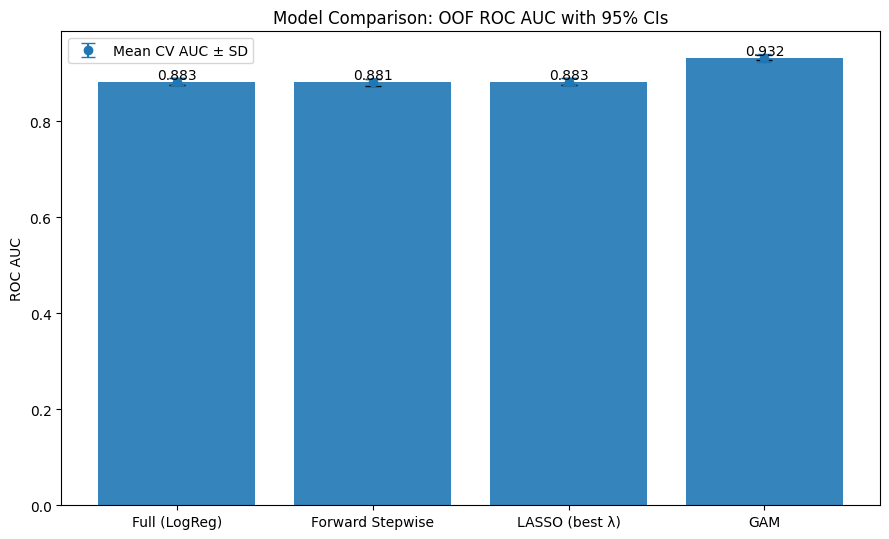

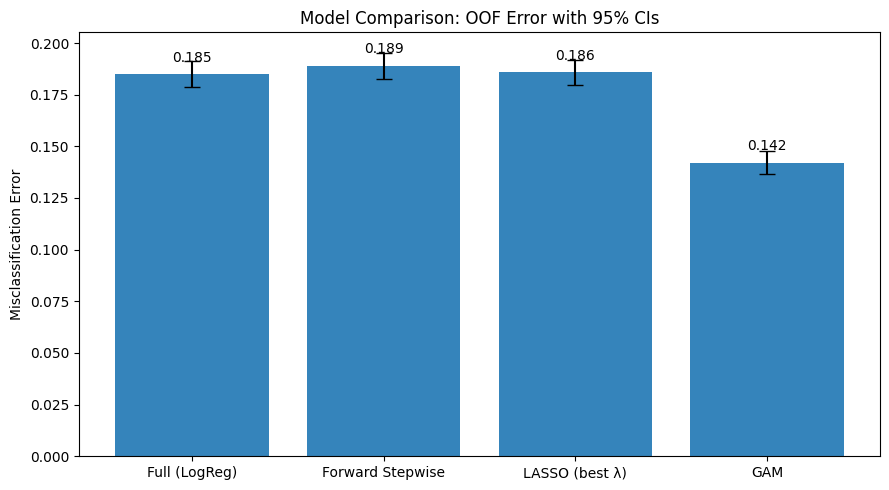

,Model,OOF AUC,AUC 95% CI (low),AUC 95% CI (high),OOF Error,Error 95% CI (low),Error 95% CI (high),Mean CV AUC,Std CV AUC,Selected Features,Best λ (1/C),Best C,Non-zero Coefs
0,Full (LogReg),0.8825,0.8753,0.8893,0.1848,0.1787,0.1911,0.8826,0.0071,nan,nan,nan,nan
1,Forward Stepwise,0.8809,0.8740,0.8876,0.1891,0.1826,0.1954,0.8810,0.0063,5.000000,nan,nan,nan
2,LASSO (best λ),0.8826,0.8754,0.8893,0.1859,0.1798,0.1919,0.8827,0.0071,nan,10.000000,0.100000,11.000000
3,GAM,0.9321,0.9268,0.9371,0.1421,0.1364,0.1477,0.9321,0.0081,nan,nan,nan,nan


In [43]:
def _mean_std_from_folds(res: dict):
    """Return (mean_auc, std_auc) from either fold_summary or fold_metrics."""
    if "fold_summary" in res and res["fold_summary"] is not None:
        return float(res["fold_summary"]["roc_auc_mean"]), float(res["fold_summary"]["roc_auc_std"])
    auc_vals = np.array([m["roc_auc"] for m in res.get("fold_metrics", [])], dtype=float)
    if auc_vals.size == 0:
        return np.nan, np.nan
    return float(np.mean(auc_vals)), float(np.std(auc_vals, ddof=1)) if auc_vals.size > 1 else 0.0


def plot_model_comparison_extended(
    res_full: dict,
    res_step: dict,
    res_lasso_best: dict,
    res_gam: dict,
    lasso_best_row: dict | None = None,   # optional: from lasso_grid_df.loc[best_idx].to_dict()
    stepwise_selected_features: list | None = None  # optional: pass selected_feature_names
) -> None:
    # Assemble core metrics
    labels = ["Full (LogReg)", "Forward Stepwise", "LASSO (best λ)", "GAM"]
    results = [res_full, res_step, res_lasso_best, res_gam]

    aucs = [r["overall"]["roc_auc"] for r in results]
    auc_cis = [r["bootstrap_ci"]["auc_ci"] for r in results]
    lower_err_auc = [aucs[i] - auc_cis[i][0] for i in range(len(results))]
    upper_err_auc = [auc_cis[i][1] - aucs[i] for i in range(len(results))]
    yerr_auc = np.vstack([lower_err_auc, upper_err_auc])

    errs = [r["overall"]["misclassification_error"] for r in results]
    err_cis = [r["bootstrap_ci"]["error_ci"] for r in results]
    lower_err_err = [errs[i] - err_cis[i][0] for i in range(len(results))]
    upper_err_err = [err_cis[i][1] - errs[i] for i in range(len(results))]
    yerr_err = np.vstack([lower_err_err, upper_err_err])

    # Fold-level summaries (mean/std AUC)
    fold_means, fold_stds = zip(*[_mean_std_from_folds(r) for r in results])

    # ---- Plot 1: ROC AUC with 95% CIs + overlay mean CV AUC (±1 SD)
    plt.figure(figsize=(9, 5.5))
    bars = plt.bar(labels, aucs, yerr=yerr_auc, capsize=6, alpha=0.9)
    # Overlay mean CV AUC as points with error bars
    x = np.arange(len(labels))
    plt.errorbar(x, fold_means, yerr=fold_stds, fmt='o', capsize=5, label='Mean CV AUC ± SD')
    for i, v in enumerate(aucs):
        plt.text(i, v + 0.006, f"{v:.3f}", ha='center')
    plt.ylabel("ROC AUC")
    plt.title("Model Comparison: OOF ROC AUC with 95% CIs")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---- Plot 2: Misclassification Error with 95% CIs
    plt.figure(figsize=(9, 5.0))
    bars2 = plt.bar(labels, errs, yerr=yerr_err, capsize=6, alpha=0.9)
    for i, v in enumerate(errs):
        plt.text(i, v + 0.006, f"{v:.3f}", ha='center')
    plt.ylabel("Misclassification Error")
    plt.title("Model Comparison: OOF Error with 95% CIs")
    plt.tight_layout()
    plt.show()

    # ---- Tabular summary
    summary_rows = []
    for lbl, r, mean_auc, std_auc in zip(labels, results, fold_means, fold_stds):
        row = {
            "Model": lbl,
            "OOF AUC": r["overall"]["roc_auc"],
            "AUC 95% CI (low)": r["bootstrap_ci"]["auc_ci"][0],
            "AUC 95% CI (high)": r["bootstrap_ci"]["auc_ci"][1],
            "OOF Error": r["overall"]["misclassification_error"],
            "Error 95% CI (low)": r["bootstrap_ci"]["error_ci"][0],
            "Error 95% CI (high)": r["bootstrap_ci"]["error_ci"][1],
            "Mean CV AUC": mean_auc,
            "Std CV AUC": std_auc,
        }
        summary_rows.append(row)

    # Optional: add sparsity and feature-count diagnostics
    if lasso_best_row is not None:
        for row in summary_rows:
            if row["Model"].startswith("LASSO"):
                row["Best λ (1/C)"] = float(lasso_best_row.get("lambda", np.nan))
                row["Best C"] = float(lasso_best_row.get("C", np.nan))
                row["Non-zero Coefs"] = int(lasso_best_row.get("nonzero_coef", np.nan)) if pd.notna(lasso_best_row.get("nonzero_coef", np.nan)) else np.nan
                break
    if stepwise_selected_features is not None:
        for row in summary_rows:
            if row["Model"].startswith("Forward Stepwise"):
                row["Selected Features"] = int(len(stepwise_selected_features))
                break

    comp_df = pd.DataFrame(summary_rows)
    display(comp_df.style.format({
        "OOF AUC": "{:.4f}",
        "AUC 95% CI (low)": "{:.4f}",
        "AUC 95% CI (high)": "{:.4f}",
        "OOF Error": "{:.4f}",
        "Error 95% CI (low)": "{:.4f}",
        "Error 95% CI (high)": "{:.4f}",
        "Mean CV AUC": "{:.4f}",
        "Std CV AUC": "{:.4f}",
        "Best λ (1/C)": "{:.6f}",
        "Best C": "{:.6f}"
    }))

plot_model_comparison_extended(results_full, results_stepwise, results_lasso_best, results_gam,
                                lasso_best_row=best_row.to_dict(),
                                stepwise_selected_features=selected_feature_names)


## Step 7 — Model selection and rationale

This section implements a **transparent, criteria-driven selector** that chooses the best model among four candidates—**Full Logistic Regression**, **Forward Stepwise**, **LASSO (best λ)**, and **GAM**—and returns both the **winner** and a **human-readable Markdown rationale** summarizing the decision.

**What it does**

* **Standardizes inputs:** Reads each model’s evaluation bundle (OOF AUC, OOF error, 95% bootstrap CIs; plus either fold-level summaries or raw fold metrics). If fold summaries are missing, it **recomputes mean/SD AUC from per-fold scores**.
* **Primary criterion (performance):** Ranks models by **Out-of-Fold ROC AUC**. If the top two are close (within a small tolerance) **and** their **95% CIs overlap**, the code avoids over-interpreting negligible differences.
* **Stability tie-breakers:** When AUCs are statistically similar, it prefers **higher mean CV AUC**, then **lower CV AUC standard deviation** (more stable across folds), then **lower OOF misclassification error**.
* **Parsimony final tie-break:** If metrics remain effectively tied, it favors simpler models in this order: **LASSO** (fewest non-zero coefficients), **Forward Stepwise** (fewest selected features), **Full**, **GAM**.
* **Clear rationale:** Generates a concise Markdown report listing, for every model, the **OOF AUC with 95% CI**, **Mean±SD CV AUC**, and **OOF error**, plus a brief **decision note** explaining why the chosen model won. When available, it appends **sparsity** (LASSO non-zero coefficients and λ/C) and **feature count** (Stepwise).

**Why it matters**

* Balances **point performance, uncertainty, and stability**, not just a single score.
* Reduces **false wins** from tiny numeric fluctuations by using **tolerances** (`eps_*`) and **CI overlap** checks.
* Encourages **interpretability** through parsimony when models are neck-and-neck.
* Produces a **reproducible, report-ready justification** you can paste into notebooks or competition write-ups.


### **AI-Prompt:**

Design a **model selection workflow** that chooses the best classifier among four candidates—**Full Logistic Regression**, **Forward Stepwise**, **LASSO (best λ)**, and **GAM**—using standardized evaluation results already computed elsewhere. Write it so a beginner can follow: include clear, plain-English comments explaining every step, why it’s done, and how to interpret the output.

**Inputs (assumed available in memory):**

* Four result objects (dict-like), one per model: `results_full`, `results_stepwise`, `results_lasso_best`, `results_gam`.

  * Each contains:

    * `overall`: `{"roc_auc": float, "misclassification_error": float}`
    * `bootstrap_ci`: `{"auc_ci": (low, high), "error_ci": (low, high)}`
    * Either `fold_summary` with `{"roc_auc_mean": float, "roc_auc_std": float}` **or** `fold_metrics` (list with per-fold `"roc_auc"`).
* Optional diagnostics:

  * `lasso_best_row` (dict) with `{"lambda": float, "C": float, "nonzero_coef": int}` for sparsity/hyperparam reporting.
  * `selected_feature_names` (list) from forward stepwise to report how many transformed features were selected.

**What to build:**

1. A single function (e.g., `select_model(...) -> (choice_key: str, rationale_markdown: str)`) that implements a **clear decision policy**:

   **Primary criterion:**

   * Choose the model with the **highest Out-of-Fold (OOF) ROC AUC**.
   * Treat tiny numerical differences as ties using a configurable tolerance `eps_auc`.
   * If the top two AUCs are close **and** their **95% AUC CIs overlap**, do not assume a real difference.

   **If AUCs are close and CIs overlap, use tie-breakers in order:**

   * Higher **mean CV AUC** (prefer better average performance across folds).
   * Lower **CV AUC standard deviation** (prefer more stable performance).
   * Lower **OOF misclassification error**.

   **Final parsimony tiebreak (only if metrics are effectively tied):**

   * Prefer models that are simpler/sparser in this order: **LASSO** (fewest non-zero coefficients), **Forward Stepwise** (fewest selected features), **Full Logistic**, **GAM**.
   * Only invoke this if all metrics are within tiny configurable thresholds of the current top model.

2. Helper behavior:

   * If `fold_summary` is missing, compute mean and std of per-fold AUC from `fold_metrics`.
   * Implement a small utility to check **confidence-interval overlap**.
   * Make tolerances configurable: `eps_auc`, `eps_cv`, `eps_sd`, `eps_err`.

3. Output & explanation:

   * Return the chosen model key (e.g., `"lasso"`, `"forward_stepwise"`, `"full"`, `"gam"`).
   * Return a **Markdown rationale** that concisely reports, for each model:

     * **OOF AUC** with its **95% CI**
     * **Mean±SD CV AUC**
     * **OOF error**
     * Decision note explaining **why** the winner was selected (e.g., “highest OOF AUC with non-overlapping CI” or “AUCs similar; selected higher/stabler CV AUC and lower OOF error”).
   * If available, append **parsimonious details** (e.g., “LASSO non-zero coefficients: N; best λ (1/C)=…, C=…”, “Stepwise selected features: K”).

**User-friendly requirements:**

* Assume I’m new to Python.
* Add **step-by-step comments** explaining: OOF vs CV metrics, why CIs matter, how tie-breakers work, why parsimony helps interpretability.
* Keep function I/O clean and safe (handle missing pieces gracefully).

**Deliverables:**

* A **notebook-ready** function implementing the policy above.
* A short usage example that calls the function with the four result objects (and optional diagnostics), prints the chosen model key, and prints the rationale.

**Goal:**
Provide a transparent, statistically sensible, and reproducible **model selection routine** that balances point performance, uncertainty, stability, and simplicity—ready to drop into a competition or classroom workflow.

In [44]:
def select_model_extended_fixed(
    res_full: Dict,
    res_step: Dict,
    res_lasso_best: Dict,
    res_gam: Dict,
    lasso_best_row: Dict | None = None,
    stepwise_selected_features: list | None = None,
    eps_auc: float = 5e-4,      # tiny diff in OOF AUC
    eps_cv: float = 5e-4,       # tiny diff in mean CV AUC
    eps_sd: float = 5e-4,       # tiny diff in CV AUC SD
    eps_err: float = 5e-4       # tiny diff in OOF error
) -> Tuple[str, str]:
    import numpy as np

    def _mean_std_from_folds(res: dict) -> Tuple[float, float]:
        if "fold_summary" in res and res["fold_summary"] is not None:
            return float(res["fold_summary"]["roc_auc_mean"]), float(res["fold_summary"]["roc_auc_std"])
        auc_vals = np.array([m.get("roc_auc", np.nan) for m in res.get("fold_metrics", [])], dtype=float)
        auc_vals = auc_vals[~np.isnan(auc_vals)]
        if auc_vals.size == 0:
            return np.nan, np.nan
        return float(np.mean(auc_vals)), float(np.std(auc_vals, ddof=1)) if auc_vals.size > 1 else 0.0

    def _pack(name: str, res: Dict) -> Dict:
        auc = float(res["overall"]["roc_auc"])
        err = float(res["overall"]["misclassification_error"])
        auc_ci = tuple(res["bootstrap_ci"]["auc_ci"])
        err_ci = tuple(res["bootstrap_ci"]["error_ci"])
        mean_cv, sd_cv = _mean_std_from_folds(res)
        return dict(name=name, auc=auc, err=err, auc_ci=auc_ci, err_ci=err_ci,
                    mean_cv_auc=mean_cv, std_cv_auc=sd_cv)

    def _ci_overlap(ci_a, ci_b) -> bool:
        return not (ci_a[1] < ci_b[0] or ci_b[1] < ci_a[0])

    # Assemble candidates in a stable order
    models = [
        _pack("full", res_full),
        _pack("forward_stepwise", res_step),
        _pack("lasso", res_lasso_best),
        _pack("gam", res_gam),
    ]
    md = {m["name"]: m for m in models}

    # 1) Primary: highest OOF AUC
    by_auc = sorted(models, key=lambda d: d["auc"], reverse=True)
    top, second = by_auc[0], by_auc[1]
    auc_gap = top["auc"] - second["auc"]
    overlap = _ci_overlap(top["auc_ci"], second["auc_ci"])

    # If clearly better by AUC (beyond eps or non-overlapping CIs), pick top
    if (auc_gap > eps_auc) and (not overlap or auc_gap > 2*eps_auc):
        choice = top["name"]
        reason = f"Highest OOF AUC ({top['auc']:.4f}); {'non-overlapping' if not overlap else 'overlapping'} CI vs next best."
    else:
        # 2) AUCs close: use mean CV AUC
        by_cv_mean = sorted(models, key=lambda d: (np.nan_to_num(d["mean_cv_auc"], nan=-1)), reverse=True)
        best_cv = by_cv_mean[0]
        # 3) If CV means close, pick lower CV SD (stability)
        close_mean = [m for m in models if abs((m["mean_cv_auc"] or 0) - (best_cv["mean_cv_auc"] or 0)) <= eps_cv]
        if len(close_mean) > 1:
            best_cv = sorted(close_mean, key=lambda d: (np.nan_to_num(d["std_cv_auc"], nan=1e9)))[0]
        # 4) If still close, pick lower OOF error
        still_close = [m for m in close_mean if abs((m["std_cv_auc"] or 0) - (best_cv["std_cv_auc"] or 0)) <= eps_sd]
        if len(still_close) > 1:
            best_cv = sorted(still_close, key=lambda d: d["err"])[0]
        choice = best_cv["name"]
        reason = (f"AUCs are similar (gap ≤ {eps_auc:.1e} and CIs overlap). "
                  f"Selected higher/stabler CV AUC ({best_cv['mean_cv_auc']:.4f}±{best_cv['std_cv_auc']:.4f}) "
                  f"and lower OOF error where applicable.")

    # 5) Parsimony ONLY if everything is effectively tied to the **top** model
    top_ref = by_auc[0]  # anchor tiny comparisons to the actual top-by-AUC model
    def _near_tied(m):
        return (abs(m["auc"] - top_ref["auc"]) <= eps_auc and
                abs((m["mean_cv_auc"] or 0) - (top_ref["mean_cv_auc"] or 0)) <= eps_cv and
                abs((m["std_cv_auc"] or 0) - (top_ref["std_cv_auc"] or 0)) <= eps_sd and
                abs(m["err"] - top_ref["err"]) <= eps_err)

    near_group = [m for m in models if _near_tied(m)]
    if len(near_group) > 1:
        # Prefer sparsity/compactness: LASSO → Stepwise → Full → GAM
        def _parsimony_rank(m):
            if m["name"] == "lasso":
                # fewer non-zero coefs is better; if unknown, rank slightly worse
                nnz = None if lasso_best_row is None else lasso_best_row.get("nonzero_coef", None)
                return (0, nnz if isinstance(nnz, (int, float)) else 1e9)
            if m["name"] == "forward_stepwise":
                k = None if stepwise_selected_features is None else len(stepwise_selected_features)
                return (1, k if isinstance(k, (int, float)) else 1e9)
            if m["name"] == "full":
                return (2, 1e9)
            if m["name"] == "gam":
                return (3, 1e9)
            return (9, 1e9)

        current = md[choice]
        best_pars = sorted(near_group, key=_parsimony_rank)[0]
        if _parsimony_rank(best_pars) < _parsimony_rank(current):
            choice = best_pars["name"]
            reason += " Parsimony tiebreak favored a sparser/simpler model."

    # Build rationale markdown
    def _fmt_ci(ci): return f"({ci[0]:.4f}, {ci[1]:.4f})"
    rationale = (
        f"**Selected model:** **{choice.replace('_',' ').title()}**\n\n"
        f"**Primary (OOF AUC):** "
        f"Full={md['full']['auc']:.4f} {_fmt_ci(md['full']['auc_ci'])}, "
        f"Stepwise={md['forward_stepwise']['auc']:.4f} {_fmt_ci(md['forward_stepwise']['auc_ci'])}, "
        f"LASSO={md['lasso']['auc']:.4f} {_fmt_ci(md['lasso']['auc_ci'])}, "
        f"GAM={md['gam']['auc']:.4f} {_fmt_ci(md['gam']['auc_ci'])}.\n"
        f"**Stability (Mean±SD CV AUC):** "
        f"Full={md['full']['mean_cv_auc']:.4f}±{md['full']['std_cv_auc']:.4f}, "
        f"Stepwise={md['forward_stepwise']['mean_cv_auc']:.4f}±{md['forward_stepwise']['std_cv_auc']:.4f}, "
        f"LASSO={md['lasso']['mean_cv_auc']:.4f}±{md['lasso']['std_cv_auc']:.4f}, "
        f"GAM={md['gam']['mean_cv_auc']:.4f}±{md['gam']['std_cv_auc']:.4f}.\n"
        f"**Secondary (OOF Error):** "
        f"Full={md['full']['err']:.4f}, Stepwise={md['forward_stepwise']['err']:.4f}, "
        f"LASSO={md['lasso']['err']:.4f}, GAM={md['gam']['err']:.4f}.\n"
        f"**Decision note:** {reason}"
    )
    # Optional addenda
    addenda = []
    if lasso_best_row is not None and "nonzero_coef" in lasso_best_row:
        add = f"LASSO non-zero coefficients: {int(lasso_best_row['nonzero_coef'])}"
        if "lambda" in lasso_best_row and "C" in lasso_best_row:
            add += f" | best λ (1/C)={lasso_best_row['lambda']:.6f}, C={lasso_best_row['C']:.6f}"
        addenda.append(add)
    if stepwise_selected_features is not None:
        addenda.append(f"Stepwise selected features: {len(stepwise_selected_features)}")
    if addenda:
        rationale += "\n" + " ".join(addenda)

    return choice, rationale

# Example use:
model_choice, rationale_text = select_model_extended_fixed(
    results_full, results_stepwise, results_lasso_best, results_gam,
    lasso_best_row=best_row.to_dict() if 'best_row' in locals() else None,
    stepwise_selected_features=selected_feature_names if 'selected_feature_names' in locals() else None
)
print("Model choice:", model_choice, "\n")
print(rationale_text)


Model choice: gam 

**Selected model:** **Gam**

**Primary (OOF AUC):** Full=0.8825 (0.8753, 0.8893), Stepwise=0.8809 (0.8740, 0.8876), LASSO=0.8826 (0.8754, 0.8893), GAM=0.9321 (0.9268, 0.9371).
**Stability (Mean±SD CV AUC):** Full=0.8826±0.0071, Stepwise=0.8810±0.0063, LASSO=0.8827±0.0071, GAM=0.9321±0.0081.
**Secondary (OOF Error):** Full=0.1848, Stepwise=0.1891, LASSO=0.1859, GAM=0.1421.
**Decision note:** Highest OOF AUC (0.9321); non-overlapping CI vs next best.
LASSO non-zero coefficients: 11 | best λ (1/C)=10.000000, C=0.100000 Stepwise selected features: 5


## Step 8 — Final training on the full training data

In this section we **finalize the model** selected in the previous step (one of **Full Logistic Regression**, **Forward Stepwise**, **LASSO (best λ)**, or **GAM**) and train it on the **entire training set** to maximize learning before producing competition/test predictions. The code first builds the correct pipeline for the chosen model, then fits it end-to-end with the same preprocessing used during evaluation to avoid any mismatch or leakage.

To aid **traceability and reproducibility**, we compute how many **transformed features** the pipeline actually uses. A small helper safely clones and fits the preprocessor on `X` purely for reporting, returning the transformed feature count (and names when available). For stepwise models, we report the number of **selected** transformed features; for LASSO/GAM/Full, we report the full transformed dimensionality.

After training, the code:

* **Persists** the fitted pipeline to `final_model.joblib` (ready for downstream scoring).
* Writes a compact **metadata JSON** (`final_model_metadata.json`) capturing the timestamp, seed, selected model, feature count, an optional preview of feature names, and model-specific diagnostics (e.g., LASSO’s best λ/C and non-zero coefficient count, Stepwise’s number of selected features).
* Prints friendly confirmations, including the **selection rationale** if available, so the final choice is easy to justify in reports.

This makes the notebook **deployment-ready**: you end with a single serialized model plus auditable metadata that documents exactly **what** was trained, **how**, and **why**.


### **AI-Prompt:**

Create a **final training and persistence workflow** for a binary classification project that selects among four already-evaluated candidates—**Full Logistic Regression**, **Forward Stepwise**, **LASSO (best λ)**, and **GAM**—and then fits the chosen pipeline on the **entire training set**. The workflow must be notebook-ready and heavily commented in plain English so a newcomer can follow every step.

**Assume these objects already exist in memory:**

* `model_choice` (one of: `"full"`, `"forward_stepwise"`, `"lasso"`, `"gam"`)
* Preprocessing and pipelines: `preprocessor`, `full_pipeline`, `refined_pipeline` (stepwise), `gam_pipeline`
* Data: `X` (features as DataFrame), `y` (binary target as Series), `SEED` (int)
* Stepwise artifacts: `selected_idx` (list of selected column indices), `selected_feature_names` (list; may be absent)
* LASSO artifacts: `best_row` (row/dict with at least `C`, optionally `lambda`, `nonzero_coef`)
* Optional text: `rationale_text` (Markdown string explaining why the model was chosen)
* Utility: `get_transformed_feature_names(preprocessor_like)` that returns names after preprocessing

**What the workflow must do (with clear comments):**

1. **Helper to count transformed features**

   * Build a small function that **clones and fits** the provided `preprocessor` on `X`, then returns:

     * The **number of transformed features**.
     * The **feature names** if available; otherwise `None`.
   * Explain why cloning/fitting just for counting is safe and does **not** affect training.

2. **Construct the final pipeline based on `model_choice`**

   * `"full"`: use the already-defined `full_pipeline`. Try to get transformed feature names from an existing fitted preprocessor if available; otherwise call the helper.
   * `"forward_stepwise"`: use `refined_pipeline` (preprocess → selector → classifier). Feature count equals `len(selected_idx)`. Prefer `selected_feature_names` if available.
   * `"lasso"`: rebuild a final pipeline using **L1 logistic regression** with **C** from `best_row["C"]` (remind that `C = 1/λ`). Use the shared `preprocessor`. Count features via the helper.
   * `"gam"`: use the already-defined `gam_pipeline`; count features via the helper.
   * Validate `model_choice` and raise a clear error if it’s unknown.

3. **Fit on the entire training data**

   * Fit the chosen pipeline on `X, y`.
   * Explain why we now train on **all** data (after model selection), and caution about reusing any cross-validation objects (we are not).

4. **Persist the trained model**

   * Save the fitted pipeline to `final_model.joblib` using a standard serialization library.
   * Print a friendly confirmation message.

5. **Persist lightweight metadata (JSON)**

   * Write `final_model_metadata.json` capturing:

     * `timestamp` in UTC ISO 8601 with “Z” suffix
     * `seed`
     * `model_choice`
     * `feature_count`
     * `selected_features_preview` (first ~25 names if available; otherwise `null`)
     * `rationale` (if provided)
     * If winner is LASSO: include `lambda` (if available), `C`, and `nonzero_coef` (if available)
     * If winner is Stepwise: include `n_selected`
   * Explain why metadata aids **reproducibility** and quick auditing.

6. **User-facing printouts**

   * Print the save location for the model, the number of transformed features used, and (if present) the selection rationale text.

7. **Beginner notes & safety**

   * Add comments clarifying common pitfalls (e.g., not leaking CV artifacts, why we re-fit on full training data).
   * Be defensive with missing optional fields (`selected_feature_names`, `best_row["lambda"]`, `best_row["nonzero_coef"]`) and handle gracefully.

**Output:**

* A single, well-commented, notebook-ready block that:

  * Builds the correct final pipeline based on `model_choice`
  * Fits on `X, y`
  * Saves `final_model.joblib`
  * Saves `final_model_metadata.json` with the fields above
  * Prints concise confirmations and the feature count

**Tone & style:**

* Plain-English comments at each step.
* Short explanations of *why* each action is taken (e.g., cloning preprocessor, re-fitting on all data, what metadata fields mean).
* Keep variable names readable and consistent with the assumptions above.



In [45]:
# === Final Training & Persistence (aware of Full / Stepwise / LASSO / GAM) ===
from sklearn.base import clone
import joblib
import json
from datetime import datetime

def _transformed_feature_count(preprocessor, X):
    """Fit a cloned preprocessor on X and return (#features, optional feature_names)."""
    pp = clone(preprocessor)
    Xt = pp.fit_transform(X)
    try:
        names = get_transformed_feature_names(pp)
        return len(names), names
    except Exception:
        return Xt.shape[1], None

# Build the final pipeline based on the chosen model
if model_choice == "full":
    # already defined in Step 4
    final_pipeline = full_pipeline
    # use the temp preprocessor fitted earlier (_tmp) if available, else recompute
    try:
        final_feature_count = len(get_transformed_feature_names(_tmp.named_steps['preprocess']))
        final_feature_names = get_transformed_feature_names(_tmp.named_steps['preprocess'])
    except Exception:
        final_feature_count, final_feature_names = _transformed_feature_count(preprocessor, X)

elif model_choice == "forward_stepwise":
    # already defined as refined_pipeline (preprocess -> selector -> clf)
    final_pipeline = refined_pipeline
    final_feature_count = len(selected_idx)
    final_feature_names = selected_feature_names if 'selected_feature_names' in locals() else None

elif model_choice == "lasso":
    # rebuild a LASSO pipeline using the best lambda (1/C) discovered earlier
    best_C = float(best_row["C"]) if 'best_row' in locals() else 1.0
    lasso_final = LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=best_C,
        class_weight="balanced",
        max_iter=2000,
        random_state=SEED,
    )
    final_pipeline = Pipeline(steps=[("preprocess", preprocessor), ("clf", lasso_final)])
    # LASSO consumes the full transformed design matrix
    final_feature_count, final_feature_names = _transformed_feature_count(preprocessor, X)

elif model_choice == "gam":
    # already defined as gam_pipeline
    final_pipeline = gam_pipeline
    # GAM consumes the full transformed design matrix (numeric splines + linear OHE)
    final_feature_count, final_feature_names = _transformed_feature_count(preprocessor, X)

else:
    raise ValueError(f"Unknown model_choice: {model_choice}")

# Fit the chosen pipeline on the entire training data
final_pipeline.fit(X, y)

# Persist model
model_path = "final_model.joblib"
joblib.dump(final_pipeline, model_path)

# --- Optional: persist lightweight metadata for reproducibility/reporting
metadata = {
    "timestamp": datetime.utcnow().isoformat() + "Z",
    "seed": int(SEED),
    "model_choice": model_choice,
    "feature_count": int(final_feature_count),
    "selected_features_preview": (final_feature_names[:25] if isinstance(final_feature_names, list) else None),
    # Attach selection rationale if available
    "rationale": rationale_text if 'rationale_text' in locals() else None,
    # LASSO diagnostics if available
    "lasso_best": {
        "lambda": float(best_row["lambda"]) if ('best_row' in locals() and "lambda" in best_row) else None,
        "C": float(best_row["C"]) if ('best_row' in locals() and "C" in best_row) else None,
        "nonzero_coef": int(best_row["nonzero_coef"]) if ('best_row' in locals() and "nonzero_coef" in best_row and pd.notna(best_row["nonzero_coef"])) else None
    } if model_choice == "lasso" else None,
    # Stepwise diagnostics if available
    "stepwise": {
        "n_selected": int(len(selected_idx)) if ('selected_idx' in locals()) else None
    } if model_choice == "forward_stepwise" else None
}

with open("final_model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print(f"Persisted final model to {model_path}")
print("Number of transformed features used:", final_feature_count)
if metadata.get("rationale"):
    print("\nSelection rationale:\n", metadata["rationale"])
print("Saved metadata to final_model_metadata.json")


Persisted final model to final_model.joblib
Number of transformed features used: 11

Selection rationale:
 **Selected model:** **Gam**

**Primary (OOF AUC):** Full=0.8825 (0.8753, 0.8893), Stepwise=0.8809 (0.8740, 0.8876), LASSO=0.8826 (0.8754, 0.8893), GAM=0.9321 (0.9268, 0.9371).
**Stability (Mean±SD CV AUC):** Full=0.8826±0.0071, Stepwise=0.8810±0.0063, LASSO=0.8827±0.0071, GAM=0.9321±0.0081.
**Secondary (OOF Error):** Full=0.1848, Stepwise=0.1891, LASSO=0.1859, GAM=0.1421.
**Decision note:** Highest OOF AUC (0.9321); non-overlapping CI vs next best.
LASSO non-zero coefficients: 11 | best λ (1/C)=10.000000, C=0.100000 Stepwise selected features: 5
Saved metadata to final_model_metadata.json


## Step 9 — Predict on the test set and export CSV

This section loads the **final trained pipeline**, aligns the **test set schema** to what the pipeline’s preprocessor expects, generates **class-1 probabilities**, and writes a **competition-ready `submission.csv`** with a robust ID column.


**Key Steps**

1. **Model Loading**
   The persisted predictive model pipeline is reloaded from disk. This guarantees that the exact trained model is used consistently at inference time. A fail-fast check ensures the file exists before proceeding.

2. **Test Data Preparation**
   The test dataset is loaded, and the script automatically detects the identifier column. Because identifier names may vary (`id`, `CustomerId`, `CostumerId`, etc.), the code applies a detection routine that searches for expected variants. If no known name is found, it falls back on a heuristic that selects a column with unique, non-missing values.

3. **Identifier Integrity**
   The detected identifier column is re-read from the raw file with an enforced string type. This prevents accidental corruption of identifiers, such as conversion to floats, loss of leading zeros, or display in scientific notation. The identifier is then normalized under the standard name `id`.

4. **Feature Matrix Construction**
   All non-feature columns (`id`, potential variants, and any target columns like `Exited`) are dropped, leaving only predictors for the model. The pipeline’s preprocessing step is then used to align the test features with the expected schema. Missing columns are filled with `NaN`, and the column order is matched precisely.

5. **Prediction**
   The pipeline generates predicted probabilities for the positive outcome class. If the model supports probability prediction (`predict_proba`), the probabilities are taken directly. Otherwise, the script falls back to a decision function and applies a logistic transformation.

6. **Submission File Assembly**
   A submission DataFrame is created with exactly two columns:

   * `id` (the preserved identifiers from the test file)
   * `Exited` (the predicted probability of exit)

   The file is written to disk without altering row order, ensuring alignment between identifiers and predictions. Sanity checks validate that the number of rows in the submission matches the test set.

7. **Diagnostics and Validation**
   Additional routines confirm the correctness of the submission:

   * Schema verification (only `id` and `Exited`).
   * Count comparison between test and submission.
   * Set-level checks to confirm that every identifier in the test appears in the submission and vice versa.
   * Positional alignment checks to confirm that identifiers match row-for-row.
   * Reporting of discrepancies, including mismatched IDs or indices, to help pinpoint and resolve issues.

**Purpose and Rationale**

This robust submission workflow ensures that the exported predictions satisfy all competition requirements: correct schema, faithful preservation of test identifiers, row-by-row alignment, and valid probability ranges. By embedding validation and diagnostics, it provides a safeguard against silent errors that could otherwise invalidate results or reduce the model’s standing in leaderboard evaluations.

This section therefore functions as the critical final step of the predictive modeling pipeline, converting trained models into valid, reliable, and competition-ready outputs.


### **AI-Prompt**

Design a robust, production-grade inference and submission workflow for a supervised binary classification project that predicts the probability of the positive class for each record in a test dataset and exports a competition-ready submission file.

**Context and constraints**

* Test data are provided in a CSV file. The identifier column name may vary across datasets (e.g., id, ID, Id, CustomerId, CustomerID, customerId, CostumerId).
* Identifiers must be preserved exactly as they appear in the CSV (no numeric coercion, no scientific notation, no “.0” suffixes).
* The final submission must contain exactly two columns in this order: `id`, `Exited`, where:

  * `id` is the exact identifier from the test file (string).
  * `Exited` is the predicted probability of the positive class in [0,1], **rendered in the CSV with exactly five digits after the decimal point** (e.g., `0.12345`, `1.00000`). Trailing zeros must be preserved.
* Row order in the submission must match the row order of the input test CSV unless explicitly stated otherwise.

**Inputs**

* Path to the persisted model pipeline file.
* Path to the test CSV file.
* Desired output path for the submission CSV.

**Outputs**

1. A submission CSV with columns:

   * `id`: the exact identifier values from the test CSV (string type).
   * `Exited`: the predicted probability for the positive class (float in [0,1]) **and serialized to disk with exactly five decimal places**.
2. Console logs (or equivalent) confirming schema, counts, integrity checks, and **formatting enforcement**.
3. Optional diagnostic report to help debug identifier mismatches and **formatting violations**.

**Functional requirements**

1. Load the persisted pipeline from disk. Fail fast with a clear error if the file is missing.
2. Read the test CSV for features.
3. Detect the identifier column using the following logic:

   * Prefer a pre-defined list of common identifier names (case variants included).
   * If none are found, select a single column whose values are all non-null and unique across all rows.
   * If still ambiguous, raise a descriptive error instructing the user to supply/rename an identifier column.
4. Re-read the identifier column only, enforcing string typing at read time to guarantee lossless fidelity (no numeric casting). Treat this column as the single source of truth for identifiers throughout the workflow.
5. Build the feature matrix by dropping the identifier column and any target artifacts if present (e.g., `Exited`).
6. If the pipeline includes a preprocessing step that expects specific columns, align the test feature columns to those expectations in a column-wise manner only (preserve row order). For missing expected columns, create them with NA values; for unexpected extras, drop them.
7. Generate probability predictions for the positive class:

   * Prefer `predict_proba` (use the second column).
   * If unavailable, use `decision_function` and map scores to (0,1) via a logistic transform.
   * If neither is available, fail with a clear, actionable error.
   * Clip to [0,1] for numerical safety.
8. Construct the submission DataFrame with exactly two columns, in order: `id`, `Exited`. Keep `id` as string.
9. Do not sort unless required by the competition; preserve original file order.
10. **Persist the submission with `Exited` rendered to exactly five decimal places:**

    * Use a serialization method that preserves trailing zeros, e.g., `DataFrame.to_csv(..., float_format="%.5f")`.
    * Alternatively (language-agnostic): convert the `Exited` column to strings via fixed-point formatting, e.g., `f"{p:.5f}"`, ensuring the decimal separator is `.`.
    * Ensure no thousands separators or locale-specific formatting are introduced.
11. Write the submission to disk with index disabled.

**Validation and integrity checks (must run automatically)**

* Assert the submission has exactly two columns: `["id", "Exited"]`.
* Assert `0 ≤ Exited ≤ 1` for all rows (operate on numeric probabilities before formatting).
* Assert row counts between test and submission match.
* Compare the set of unique `id`s in the submission against those in the test CSV (read as strings). They must match exactly.
* Optionally verify positional alignment (element-wise equality of `id` in original test order vs. submission order) and print True/False.
* **Format compliance check (required):** after writing, re-read the CSV with `Exited` as string and verify every value matches the regex `^\d+\.\d{5}$`. Fail with an actionable error if any row violates the five-decimal constraint and print a few offending examples.

**Diagnostics (print concise, actionable findings)**

* If `id` sets differ, print the first few identifiers that exist only in test and only in submission.
* If positional alignment fails, print the first few mismatched row indices along with the pair of `id` values (test vs. submission).
* Echo the detected identifier column name used as the source of truth.
* **If format compliance fails,** print sample rows with the non-compliant `Exited` strings and instructions to enforce fixed-point formatting (e.g., `float_format="%.5f"` or fixed-point string formatting).

**Edge-case handling**

* Identifier column appears with unexpected capitalization or common misspelling (e.g., `CostumerId`).
* Identifier stored as large integers, floats, or strings with leading zeros; ensure the exported `id` values match the CSV exactly by enforcing string dtype at read time.
* Test CSV accidentally includes a target column; ensure it is dropped from features.
* Pipeline’s preprocessor expects columns not present in test; create missing columns as NA and align column order without altering row order.
* Estimator lacks `predict_proba`; fall back to `decision_function` with logistic mapping; otherwise raise a clear error.
* **Locale differences:** force `.` as the decimal separator and avoid thousands separators to keep the `^\d+\.\d{5}$` contract.

**Deliverables**

* Fully commented, readable implementation that performs the above workflow end-to-end.
* Inline comments that explain every step in plain language for non-experts, including why each step is necessary (e.g., “read IDs as strings to prevent scientific notation or .0 artifacts”; “use fixed-point formatting to guarantee exactly five decimals”).
* Console prints that summarize success (file path, shape, schema) and any detected anomalies.
* A short “How to run” note at the top specifying where to set the three paths (model file, test file, output file).

**Acceptance criteria**

* The submission CSV passes all validation checks, including exact set equality of `id`s and correct schema/order.
* Predictions are probabilities in [0,1], aligned row-by-row with the original test file.
* **Every `Exited` value is serialized in the CSV with exactly five digits after the decimal point (e.g., `0.12345`, `1.00000`), verified by a post-write regex check.**
* The workflow fails loudly and informatively when assumptions are violated (missing model, missing/ambiguous `id`, no probability-like outputs, **formatting non-compliance**), providing clear remediation guidance.

**Instruction to the model**

Produce the complete solution described above with thorough, plain-English comments for each step so that a reader unfamiliar with programming can understand the purpose and rationale of the operations. Include the validation and diagnostics routines, and **explicitly implement both the fixed-point five-decimal serialization of `Exited` and the post-write regex validation** to guarantee the final output matches the contract exactly.


In [49]:
# === Robust submission: enforce exact `id` strings from test.csv and 5-decimal Exited ===
import os
import re
import numpy as np
import pandas as pd
import joblib

MODEL_PATH = "final_model.joblib"
TEST_PATH  = "test.csv"
OUT_PATH   = "submission.csv"

# 0) Helpers
CANDIDATE_ID_NAMES = ["id", "ID", "Id", "iD", "CustomerId", "CustomerID", "customerId", "CostumerId"]

def detect_id_column(df: pd.DataFrame) -> str:
    # 1) exact/case-variant matches
    for c in CANDIDATE_ID_NAMES:
        if c in df.columns:
            return c
    # 2) heuristic fallback: pick a single column with unique values == nrows and no nulls
    n = len(df)
    for c in df.columns:
        if df[c].isna().sum() == 0 and df[c].nunique(dropna=False) == n:
            return c
    raise KeyError("Could not detect an identifier column. Please ensure test.csv contains `id` or an ID-like column.")

def _required_columns_from_preprocessor(pp) -> list[str]:
    req = []
    if hasattr(pp, "transformers_"):
        for name, trans, cols in pp.transformers_:
            if name == "remainder":
                continue
            if isinstance(cols, (list, tuple, np.ndarray, pd.Index)):
                req.extend(list(cols))
    return req

# 1) Load model
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Cannot find {MODEL_PATH}.")
pipe = joblib.load(MODEL_PATH)

# 2) Load test data (for features)
test_feat = pd.read_csv(TEST_PATH)

# 3) Identify the ID column name from the feature load
id_col_in_test = detect_id_column(test_feat)

# 4) Re-read ONLY the ID column as STRING to avoid float/scientific-notation corruption
id_series = pd.read_csv(TEST_PATH, usecols=[id_col_in_test], dtype={id_col_in_test: "string"})[id_col_in_test]
id_series = id_series.astype("string")
id_series.name = "id"  # normalize exported column name

# 5) Build X_test by dropping the detected ID and any target artifacts if present
drop_cols = [c for c in [id_col_in_test, "id", "Exited"] if c in test_feat.columns]
X_test = test_feat.drop(columns=drop_cols, errors="ignore")

# Optional: align columns to preprocessor expectation (column-wise only; preserves row order)
if "preprocess" in getattr(pipe, "named_steps", {}):
    expected = _required_columns_from_preprocessor(pipe.named_steps["preprocess"])
    if expected:
        for col in expected:
            if col not in X_test.columns:
                X_test[col] = np.nan
        X_test = X_test.reindex(columns=expected)

# 6) Predict probabilities (positive class), clip to [0,1]
if hasattr(pipe, "predict_proba"):
    proba = pipe.predict_proba(X_test)[:, 1]
elif hasattr(pipe, "decision_function"):
    scores = pipe.decision_function(X_test)
    proba = 1.0 / (1.0 + np.exp(-scores))
else:
    raise AttributeError("Final estimator lacks probability-like outputs.")
proba = np.clip(proba.astype(float), 0.0, 1.0)

# 7) Assemble submission (no sorting; preserves original row order)
submission = pd.DataFrame({
    "id": id_series.astype("string"),
    "Exited": proba
})
assert len(submission) == len(test_feat), "Row count mismatch between test and submission."

# 8) Persist with exactly 5 decimals for Exited in the CSV file
#    Use float_format to control on-disk rendering; id stays as string.
submission.to_csv(OUT_PATH, index=False, float_format="%.5f")

# 9) Post-write validation: ensure `Exited` has exactly 5 decimal digits in the file
sub_check = pd.read_csv(OUT_PATH, dtype={"id": "string", "Exited": "string"})
pattern = re.compile(r"^\d+\.\d{5}$")  # probabilities in [0,1] rendered with 5 decimals (e.g., 0.12345 or 1.00000)
if not sub_check["Exited"].map(lambda s: isinstance(s, str) and bool(pattern.match(s))).all():
    raise AssertionError("Exited column in the written CSV does not have exactly 5 decimal places for all rows.")

print(f"OK → {OUT_PATH} with schema {list(submission.columns)} and shape {submission.shape}.")
print(f"Identifier source column in test.csv: `{id_col_in_test}` (exported as `id`).")
print("Exited formatting check: PASSED (exactly 5 decimals).")

# === Diagnostics: pinpoint identifier discrepancies ===
test_raw = pd.read_csv(TEST_PATH)
id_col_diag = detect_id_column(test_raw)

# Read IDs from file as strings (ground truth)
test_ids_str = pd.read_csv(TEST_PATH, usecols=[id_col_diag], dtype={id_col_diag:"string"})[id_col_diag].astype("string")

sub_loaded = pd.read_csv(OUT_PATH, dtype={"id":"string", "Exited":"string"})

print("Schema check:", sub_loaded.columns.tolist())
print("Lengths → test:", len(test_ids_str), " submission:", len(sub_loaded))

# Set-level comparison (order-insensitive)
only_in_test = pd.Index(test_ids_str.unique()).difference(pd.Index(sub_loaded["id"].unique()))
only_in_sub  = pd.Index(sub_loaded["id"].unique()).difference(pd.Index(test_ids_str.unique()))
print("Unique IDs only in test (first 10):", list(only_in_test[:10]))
print("Unique IDs only in submission (first 10):", list(only_in_sub[:10]))

# Positional alignment (order-sensitive)
positional_equal = (test_ids_str.values == sub_loaded["id"].astype("string").values).all()
print("Positional alignment with original test order:", positional_equal)

# Show first few mismatched rows positionally, if any
if not positional_equal:
    mism = (test_ids_str != sub_loaded["id"].astype("string"))
    mismatch_positions = mism[mism].index[:10].tolist()
    print("First positional mismatch indices:", mismatch_positions)
    for i in mismatch_positions:
        print(f"Row {i}: test_id='{test_ids_str.iloc[i]}', sub_id='{sub_loaded['id'].iloc[i]}'")



OK → submission.csv with schema ['id', 'Exited'] and shape (10000, 2).
Identifier source column in test.csv: `id` (exported as `id`).
Exited formatting check: PASSED (exactly 5 decimals).
Schema check: ['id', 'Exited']
Lengths → test: 10000  submission: 10000
Unique IDs only in test (first 10): []
Unique IDs only in submission (first 10): []
Positional alignment with original test order: True


## Step 99 — Reporting and reproducibility


**Executive summary (template):** filtered out ID-like fields and `Surname`; model comparison with bootstrap CIs; final choice via AUC → error → parsimony.

**Assumptions:** median/mode imputation; OHE handle_unknown='ignore'; LogisticRegression(class_weight='balanced'); 5-fold stratified CV; 2,000 stratified bootstrap resamples.

**How to run:**
- Place `train.csv` and `test.csv` next to the notebook.
- Run all cells.
- Artifacts: `final_model.joblib`, `submission.csv`.


In [47]:

# Write requirements.txt
req = {
    'pandas': pd.__version__,
    'numpy': np.__version__,
    'scikit-learn': sklearn_version,
    'matplotlib': plt.matplotlib.__version__,
    'joblib': joblib.__version__ if hasattr(joblib, '__version__') else '>=1.3.0',
    'plotly': '>=5.0.0' if _PLOTLY_AVAILABLE else None
}
lines = [f"{k}=={v}" for k,v in req.items() if v is not None]
with open('requirements.txt','w') as f:
    f.write("\n".join(lines))
print('requirements.txt written:\n' + "\n".join(lines))


requirements.txt written:
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
matplotlib==3.10.0
joblib==1.5.2
plotly==>=5.0.0
